# Rossmann Sales — Red Neuronal con Entradas Heterogéneas
**Persona:** Fernando &nbsp;|&nbsp; **Equipo:** Oscar · Dani · Fernando

---
Arquitectura many-to-one: rama LSTM (serie temporal) + rama densa (embeddings estáticos).  
Target: `log1p(Sales)` normalizado por tienda. Tiendas objetivo: `[1, 2, 3, 4, 5, 562, 682, 733, 769]`.

## · Log de experimentos

Anotar aquí cada experimento antes de hacer `git push`.

| # | Fecha      | Bloque del notebook | Cambio principal                                               | R² medio test | Notas |
| - | ---------- | ------------------- | -------------------------------------------------------------- | ------------- | ----- |
| 0 | 09/06/2026 | Baseline            | LSTM + embeddings base                                         | 0.5342        | Primer modelo many-to-one con rama LSTM para la secuencia y rama estática con embeddings. La tienda 769 queda con R² negativo (`-0.1687`). |
| 1 | 09/06/2026 | Experimento 1       | Features `lag` y `rolling`                                     | 0.4682        | Añadir `lag` y `rolling` empeora respecto al baseline en esta configuración. La tienda 769 cae a `-0.3311`. |
| 2 | 10/06/2026 | Experimento 2       | EDA tienda 769 + nuevas features de tendencia / nivel reciente | 0.5220        | Mejora frente al experimento 1, pero no supera al baseline. La tienda 769 sigue siendo el principal problema (`-0.5821`). |
| 3 | 10/06/2026 | Experimento 3       | Modelo TCN + embeddings                                        | -1.1429       | La alternativa TCN funciona mal por tienda en esta configuración y se descarta. |
| 4 | 11/06/2026 | Experimento 4       | Reproducción E17 + calibración simple por tienda               | 0.6601 / 0.6393 | El modelo base tipo E17 alcanza `0.6601`. La calibración externa mejora 769 (`0.2332 -> 0.3142`), pero baja la media a `0.6393`, así que no se adopta. |
| 5 | 11/06/2026 | Experimento 5       | E17C: residual head global                                     | 0.6462        | La cabeza residual mejora parcialmente la tienda 769 (`0.3370`), pero no supera al E17 base en media. |
| 6 | 12/06/2026 | Experimeto 6        | E17D: selective residual head                                  | 0.6622        | Variante selectiva para tiendas problemáticas. Mejora ligeramente al E17 base en media y sube la tienda 733 a `0.4620`, aunque 769 queda por debajo de E17C (`0.2904`). |
| 7 | 12/06/2026 | Experimento 7       | Modelos por grupos de tiendas similares                        | 0.6782        | Mejor resultado del notebook. Se entrenan modelos E17 por grupos: `[2,3,5,682]`, `[1,4]`, `[733,769]` y `[562]`. 733 queda en `0.3943` y 769 en `0.3882`. |

### Mejor resultado hasta ahora

El mejor resultado obtenido en el notebook es el **Experimento 7 — modelos por grupos de tiendas similares**, con un **R² medio test de `0.6782`**.

### R² medios exactos por bloque

- Baseline: `0.5342`
- Experimento 1: `0.4682`
- Experimento 2: `0.5220`
- Experimento 3: `-1.1429`
- Experimento 4:
  - E17 base: `0.6601`
  - E17 calibrado: `0.6393`
- Experimento 5 (E17C): `0.6462`
- Experimeto 6 (E17D): `0.6622`
- Experimento 7 (group models): `0.6782`

# Baseline

## 0 · Imports y semilla

In [3]:
import sys
import os

# Añadir raíz del proyecto al path para importar src/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

import src.preprocessing as prep
import src.evaluate as ev
import src.model as mdl

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU'))} dispositivo(s)")

TensorFlow 2.21.0 | NumPy 2.4.6
GPU disponible: 0 dispositivo(s)


## 1 · Carga de datos

In [2]:
train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744


## 2 · Partición temporal

Las fechas de corte están definidas en `src/evaluate.py` como contrato del equipo.  
**No redefinir aquí.**

In [3]:
print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 3 · Preprocesado

Implementado en `src/preprocessing.py`. Ejecutar en el orden definido por el docstring del módulo.

In [4]:
# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

Filas tras clean_train: 830,918  (eliminadas: 170,681)


In [5]:
# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [6]:
# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']


In [7]:
# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

Columnas totales: 34


In [8]:
# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Train: 577,527 | Val: 70,782 | Test: 182,609


In [9]:
# Normalización por tienda — fit SOLO sobre df_train
store_stats = prep.build_store_normalizer(df_train)
df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)

# Verificar que Sales_norm tiene media ~0 y std ~1 en train
print("Sales_norm en train — media por tienda (primeras 5):")
print(df_train.groupby("Store")["Sales_norm"].mean().head())

Sales_norm en train — media por tienda (primeras 5):
Store
1   -2.024309e-09
2    4.761649e-10
3   -1.577439e-09
4    4.481552e-10
5   -9.225199e-10
Name: Sales_norm, dtype: float32


In [10]:
SEQ_LEN = 30

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"X_seq   train: {X_seq_tr.shape}    | dtype: {X_seq_tr.dtype}")
print(f"X_static train: {X_static_tr.shape} | dtype: {X_static_tr.dtype}")
print(f"y        train: {y_tr.shape}")

X_seq   train: (544077, 30, 11)    | dtype: float32
X_static train: (544077, 8) | dtype: float32
y        train: (544077,)


## 4 · Modelo

In [11]:

model = mdl.build_model(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store_enc       │ (None, 1, 16)     │     17,840 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType_enc   │ (None, 1, 2)      │          8 │ lambda_1[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment_enc  │ (None, 1, 2)      │          6 │ lambda_2[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval_… │ (None, 1, 2)      │          8 │ lambda_3[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ emb_Store_enc[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ emb_StoreType_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ emb_Assortment_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ emb_PromoInterva… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 26)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]   

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks = mdl.get_callbacks(
    checkpoint_path=os.path.join(OUTPUTS_DIR, "best_model.weights.h5")
)

history = mdl.train_model(
    model,
    X_train=(X_seq_tr, X_static_tr), y_train=y_tr,
    X_val=(X_seq_va, X_static_va),   y_val=y_va,
    callbacks=callbacks,
    epochs=50,
    batch_size=256,
)

Epoch 1/50
2124/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8237

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - loss: 0.6417 - val_loss: 0.8057 - learning_rate: 0.0010
Epoch 2/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.3293 - val_loss: 0.8558 - learning_rate: 0.0010
Epoch 3/50
2124/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2879

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.2793 - val_loss: 0.7110 - learning_rate: 0.0010
Epoch 4/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 0.2541 - val_loss: 0.7850 - learning_rate: 0.0010
Epoch 5/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - loss: 0.2426 - val_loss: 0.9214 - learning_rate: 0.0010
Epoch 6/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.2319 - val_loss: 0.8809 - learning_rate: 0.0010
Epoch 7/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.2254 - val_loss: 1.0392 - learning_rate: 0.0010
Epoch 8/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - loss: 0.2209 - val_loss: 1.0695 - learning_rate: 0.0010
Epoch 9/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - loss: 0.2087 - val_loss: 1.1454 - learning_rate: 5.0000e-04
Epoch 10/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - loss: 0.2064 - val_loss: 1.0767 - learning_rate: 5.0000e-04
Epoch 11/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - loss: 0.2041 - val_loss: 1.1630

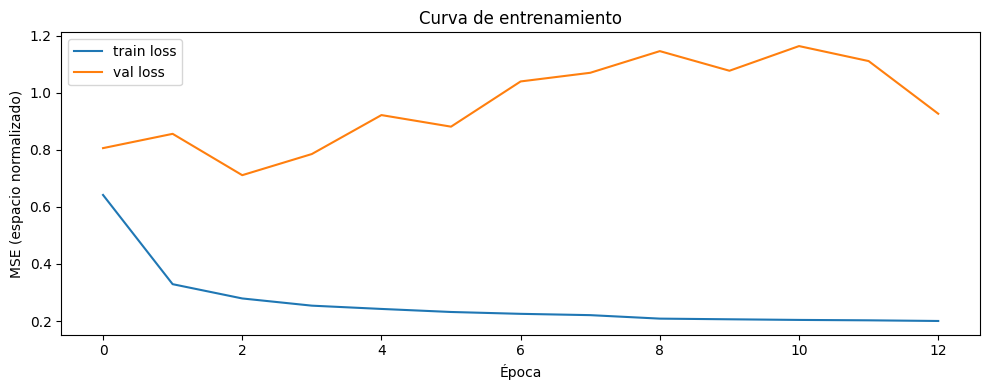

In [13]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("MSE (espacio normalizado)")
plt.legend()
plt.title("Curva de entrenamiento")
plt.tight_layout()
plt.show()

## 5 · Evaluación

In [14]:
y_pred_norm = model.predict([X_seq_te, X_static_te], verbose=0).flatten()

In [17]:
import io
from contextlib import redirect_stdout

with redirect_stdout(io.StringIO()):
    report = ev.evaluation_report(df_test, y_pred_norm, store_stats)

report_stores = report[report["Store"] != "GLOBAL"].reset_index(drop=True)
global_row = report[report["Store"] == "GLOBAL"].reset_index(drop=True)

mean_row = pd.DataFrame([{
    "Store": "MEDIA",
    "n_samples": report_stores["n_samples"].mean(),
    "R2": report_stores["R2"].mean(),
    "mean_sales_true": report_stores["mean_sales_true"].mean(),
    "mean_sales_pred": report_stores["mean_sales_pred"].mean(),
}])

report_with_mean = pd.concat([report_stores, mean_row, global_row], ignore_index=True)
display(report_with_mean.round(4))

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133.0000,0.5255,4502.6992,4785.781738
1,2,134.0000,0.6897,4981.3881,5216.654785
2,3,133.0000,0.7594,6973.1429,7242.326172
3,4,134.0000,0.6192,9863.3134,9945.009766
4,5,134.0000,0.8306,4634.5522,4806.374023
5,562,168.0000,0.6557,18096.2738,18429.464844
6,682,168.0000,0.5116,11670.5179,10928.571289
7,733,168.0000,0.3850,15514.5298,15232.516602
8,769,168.0000,-0.1687,12410.4107,11444.720703
9,MEDIA,148.8889,0.5342,9849.6476,9781.269531


In [16]:
raise SystemExit("Corta fuegos: parar aquí en Run All")

SystemExit: Corta fuegos: parar aquí en Run All

c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\Global\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Experimiento 1

Este pequeño experimento consiste en añadir variables temporales de tipo *lag* —de 1, 7, 14 y 28 días— y *rolling* —medias móviles de 7, 14 y 28 días— calculadas a partir de `Sales`. El objetivo es proporcionar al modelo información explícita sobre la evolución reciente de las ventas, para que pueda capturar mejor patrones temporales como tendencias o estacionalidad semanal.

Este tipo de variables puede ser útil incluso en modelos LSTM, ya que facilita el acceso directo a ciertos valores históricos relevantes. En particular, se busca comprobar si estas características ayudan a mejorar las predicciones de la tienda 769, cuyo comportamiento parece estar siendo peor capturado por el modelo actual.

## 1 · Descarga de datos, preprocesado y partición para train, val y test

In [18]:
# Descarga de los datos

train_raw, store_raw = prep.load_raw_data(DATA_DIR)
print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

# Partición temporal de los datos (definida en src.evaluate.py)
print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

# Preprocesado

# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")
# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")
# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")
# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")
# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)
Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]
Filas tras clean_train: 830,918  (eliminadas: 170,681)
Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
Columnas totales: 34
Train: 577,527 | Val: 70,782 | Test: 182,609


## 2 · Normalización y features de lag y rolling

In [19]:
# Normalización por tienda — fit SOLO sobre df_train
store_stats = prep.build_store_normalizer(df_train)

df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)


# ------------------------------------------------------------
# LAGS / ROLLINGS NORMALIZADOS
# IMPORTANT:
# These are created from Sales_norm, not raw Sales.
# ------------------------------------------------------------

def add_normalized_lag_rolling_features(df_train, df_val, df_test):
    df_train = df_train.copy()
    df_val   = df_val.copy()
    df_test  = df_test.copy()

    # Mark split so we can concatenate safely and split again later
    df_train["_split"] = "train"
    df_val["_split"]   = "val"
    df_test["_split"]  = "test"

    df_all = pd.concat([df_train, df_val, df_test], axis=0)
    df_all = df_all.sort_values(["Store", "Date"])

    # Remove old raw lag columns if they exist
    old_lag_cols = [
        "sales_lag_1",
        "sales_lag_7",
        "sales_lag_14",
        "sales_lag_28",
        "sales_roll_7_mean",
        "sales_roll_14_mean",
        "sales_roll_28_mean",
        "sales_roll_7_std",
    ]

    df_all = df_all.drop(
        columns=[c for c in old_lag_cols if c in df_all.columns],
        errors="ignore"
    )

    g = df_all.groupby("Store")["Sales_norm"]

    # Normalized lags
    df_all["sales_norm_lag_1"]  = g.shift(1)
    df_all["sales_norm_lag_7"]  = g.shift(7)
    df_all["sales_norm_lag_14"] = g.shift(14)
    df_all["sales_norm_lag_28"] = g.shift(28)

    # Normalized rolling features, shifted to avoid leakage
    df_all["sales_norm_roll_7_mean"] = g.transform(
        lambda x: x.shift(1).rolling(7, min_periods=3).mean()
    )

    df_all["sales_norm_roll_14_mean"] = g.transform(
        lambda x: x.shift(1).rolling(14, min_periods=5).mean()
    )

    df_all["sales_norm_roll_28_mean"] = g.transform(
        lambda x: x.shift(1).rolling(28, min_periods=7).mean()
    )

    df_all["sales_norm_roll_7_std"] = g.transform(
        lambda x: x.shift(1).rolling(7, min_periods=3).std()
    )

    lag_cols = [
        "sales_norm_lag_1",
        "sales_norm_lag_7",
        "sales_norm_lag_14",
        "sales_norm_lag_28",
        "sales_norm_roll_7_mean",
        "sales_norm_roll_14_mean",
        "sales_norm_roll_28_mean",
        "sales_norm_roll_7_std",
    ]

    # Split again
    df_train_new = df_all[df_all["_split"] == "train"].copy()
    df_val_new   = df_all[df_all["_split"] == "val"].copy()
    df_test_new  = df_all[df_all["_split"] == "test"].copy()

    # Fill NaNs using TRAIN medians only
    fill_values = df_train_new[lag_cols].median()

    df_train_new[lag_cols] = df_train_new[lag_cols].fillna(fill_values)
    df_val_new[lag_cols]   = df_val_new[lag_cols].fillna(fill_values)
    df_test_new[lag_cols]  = df_test_new[lag_cols].fillna(fill_values)

    # Clean helper column
    df_train_new = df_train_new.drop(columns=["_split"])
    df_val_new   = df_val_new.drop(columns=["_split"])
    df_test_new  = df_test_new.drop(columns=["_split"])

    return df_train_new, df_val_new, df_test_new, lag_cols


df_train, df_val, df_test, lag_cols = add_normalized_lag_rolling_features(
    df_train, df_val, df_test
)


# Verificar que Sales_norm tiene media ~0 y std ~1 en train
print("Sales_norm en train — media/std por tienda (primeras 5):")
print(df_train.groupby("Store")["Sales_norm"].agg(["mean", "std"]).head())


# Check new lag columns
print("\nLag columns added:")
print(lag_cols)

print("\nResumen de lags normalizados:")
print(df_train[lag_cols].describe().T)

Sales_norm en train — media/std por tienda (primeras 5):
               mean  std
Store                   
1     -8.434620e-10  1.0
2     -2.913009e-09  1.0
3     -1.577439e-09  1.0
4     -1.792621e-09  1.0
5     -9.013935e-10  1.0

Lag columns added:
['sales_norm_lag_1', 'sales_norm_lag_7', 'sales_norm_lag_14', 'sales_norm_lag_28', 'sales_norm_roll_7_mean', 'sales_norm_roll_14_mean', 'sales_norm_roll_28_mean', 'sales_norm_roll_7_std']

Resumen de lags normalizados:
                            count      mean       std        min       25%  \
sales_norm_lag_1         577527.0 -0.002826  0.996586 -15.024037 -0.701936   
sales_norm_lag_7         577527.0  0.003105  0.990153 -15.024037 -0.684384   
sales_norm_lag_14        577527.0  0.000587  0.984752 -15.024037 -0.677721   
sales_norm_lag_28        577527.0 -0.000252  0.972665 -15.024037 -0.657206   
sales_norm_roll_7_mean   577527.0 -0.001883  0.530094  -4.627571 -0.354941   
sales_norm_roll_14_mean  577527.0  0.001405  0.376623  -3.423

In [20]:
df_train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Store_enc', 'StoreType_enc',
       'Assortment_enc', 'PromoInterval_enc', 'StateHoliday_enc',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'has_competition', 'competition_age_years',
       'days_since_start', 'CompetitionDistance_norm', 'Sales_norm',
       'sales_norm_lag_1', 'sales_norm_lag_7', 'sales_norm_lag_14',
       'sales_norm_lag_28', 'sales_norm_roll_7_mean',
       'sales_norm_roll_14_mean', 'sales_norm_roll_28_mean',
       'sales_norm_roll_7_std'],
      dtype='str')

In [21]:
SEQ_LEN = 30

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"X_seq   train: {X_seq_tr.shape}    | dtype: {X_seq_tr.dtype}")
print(f"X_static train: {X_static_tr.shape} | dtype: {X_static_tr.dtype}")
print(f"y        train: {y_tr.shape}")

X_seq   train: (544077, 30, 11)    | dtype: float32
X_static train: (544077, 8) | dtype: float32
y        train: (544077,)


## · Modelo

Arquitectura definida en `src/model.py`. Rama LSTM + rama densa con embeddings.

In [22]:
tf.keras.backend.clear_session()

model = mdl.build_model(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store_enc       │ (None, 1, 16)     │     17,840 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType_enc   │ (None, 1, 2)      │          8 │ lambda_1[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment_enc  │ (None, 1, 2)      │          6 │ lambda_2[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval_… │ (None, 1, 2)      │          8 │ lambda_3[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ emb_Store_enc[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ emb_StoreType_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ emb_Assortment_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ emb_PromoInterva… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 26)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]   

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
tf.keras.backend.clear_session()

callbacks = mdl.get_callbacks(
    checkpoint_path=os.path.join(OUTPUTS_DIR, "best_model.weights.h5")
)

history = mdl.train_model(
    model,
    X_train=(X_seq_tr, X_static_tr), y_train=y_tr,
    X_val=(X_seq_va, X_static_va),   y_val=y_va,
    callbacks=callbacks,
    epochs=100,
    batch_size=256,
)

Epoch 1/100
2125/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7853

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 0.6059 - val_loss: 0.8597 - learning_rate: 0.0010
Epoch 2/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.3342 - val_loss: 0.9726 - learning_rate: 0.0010
Epoch 3/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2871 - val_loss: 0.8606 - learning_rate: 0.0010
Epoch 4/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2656 - val_loss: 0.9390 - learning_rate: 0.0010
Epoch 5/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2518 - val_loss: 1.0027 - learning_rate: 0.0010
Epoch 6/100
2125/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2438

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2410 - val_loss: 0.8538 - learning_rate: 0.0010
Epoch 7/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2322 - val_loss: 0.8966 - learning_rate: 0.0010
Epoch 8/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2264 - val_loss: 0.8783 - learning_rate: 0.0010
Epoch 9/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - loss: 0.2209 - val_loss: 0.9773 - learning_rate: 0.0010
Epoch 10/100
2123/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2170

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 0.2167 - val_loss: 0.8267 - learning_rate: 0.0010
Epoch 11/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 0.2128 - val_loss: 0.9898 - learning_rate: 0.0010
Epoch 12/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 0.2102 - val_loss: 1.0017 - learning_rate: 0.0010
Epoch 13/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - loss: 0.2072 - val_loss: 0.9315 - learning_rate: 0.0010
Epoch 14/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 0.2054 - val_loss: 1.0524 - learning_rate: 0.0010
Epoch 15/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2032 - val_loss: 1.0088 - learning_rate: 0.0010
Epoch 16/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.1942 - val_loss: 1.0339 - learning_rate: 5.0000e-04
Epoch 17/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 0.1929 - val_loss: 0.9987 - learning_rate: 5.0000e-04
Epoch 18/100
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 0.1920 - va

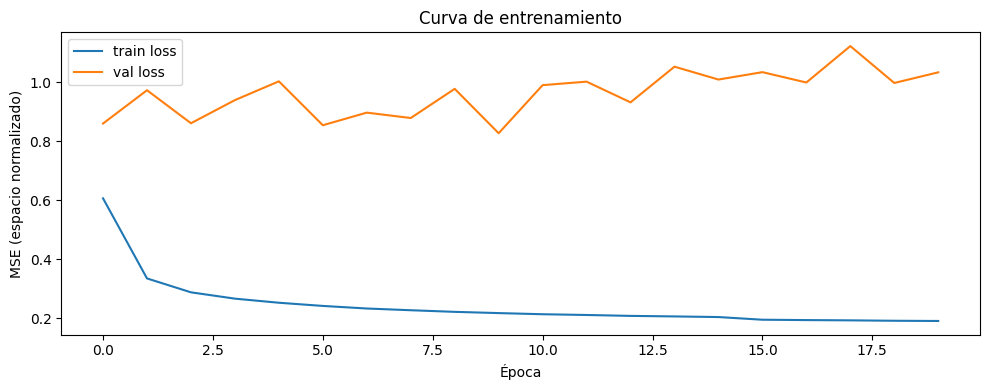

In [24]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("MSE (espacio normalizado)")
plt.legend()
plt.title("Curva de entrenamiento")
plt.tight_layout()
plt.show()

## · Evaluación

R² calculado con `src/evaluate.py` — misma función para los tres miembros del equipo.

In [25]:
y_pred_norm = model.predict([X_seq_te, X_static_te], verbose=0).flatten()

In [26]:
import io
from contextlib import redirect_stdout

with redirect_stdout(io.StringIO()):
    report = ev.evaluation_report(df_test, y_pred_norm, store_stats)

report_stores = report[report["Store"] != "GLOBAL"].reset_index(drop=True)
global_row = report[report["Store"] == "GLOBAL"].reset_index(drop=True)

mean_row = pd.DataFrame([{
    "Store": "MEDIA",
    "n_samples": report_stores["n_samples"].mean(),
    "R2": report_stores["R2"].mean(),
    "mean_sales_true": report_stores["mean_sales_true"].mean(),
    "mean_sales_pred": report_stores["mean_sales_pred"].mean(),
}])

report_with_mean = pd.concat([report_stores, mean_row, global_row], ignore_index=True)
display(report_with_mean.round(4))

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133.0000,0.4814,4502.6992,4838.067871
1,2,134.0000,0.6623,4981.3881,5342.164062
2,3,133.0000,0.6076,6973.1429,7563.828125
3,4,134.0000,0.5619,9863.3134,10094.824219
4,5,134.0000,0.7635,4634.5522,5006.046875
5,562,168.0000,0.4666,18096.2738,18980.777344
6,682,168.0000,0.6357,11670.5179,12383.256836
7,733,168.0000,0.3663,15514.5298,15502.679688
8,769,168.0000,-0.3311,12410.4107,11325.011719
9,MEDIA,148.8889,0.4682,9849.6476,10115.183594


## Reflexión sobre las variables lag y rolling

Aunque las variables *lag* y *rolling* suelen ser útiles en problemas de series temporales, en este caso no mejoraron el modelo e incluso empeoraron algunos resultados. Una posible explicación es que el modelo ya recibía una secuencia temporal de ventas pasadas, por lo que estas nuevas variables aportaban información redundante.

Además, al añadir más variables aumenta la complejidad del modelo y puede aparecer sobreajuste. Es decir, la red puede aprender patrones muy concretos del conjunto de entrenamiento que después no se repiten en test. Esto afecta especialmente a las tiendas con comportamiento más irregular.

También es posible que las medias móviles suavicen demasiado la serie, haciendo que el modelo reaccione peor ante cambios bruscos provocados por promociones, festivos u otros factores externos.

Por tanto, los resultados indican que añadir más información temporal no siempre mejora la predicción. En este caso, las variables *lag* y *rolling* pudieron introducir redundancia, ruido y sobreajuste, empeorando la capacidad de generalización del modelo.

In [27]:
raise SystemExit("Corta fuegos: parar aquí en Run All")

SystemExit: Corta fuegos: parar aquí en Run All

c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\Global\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Experimento 2

Este experimento se centra en intentar mejorar de forma significativa las predicciones de la tienda 769, ya que es la que presenta los peores resultados del conjunto evaluado. En primer lugar, se realizará un análisis exploratorio específico de esta tienda utilizando los resultados obtenidos en el primer experimento, con el objetivo de identificar posibles patrones o señales que no se hayan detectado hasta ahora.

Posteriormente, se incorporarán nuevas variables que puedan ayudar al modelo a capturar mejor el comportamiento particular de la tienda 769. Finalmente, se entrenará un nuevo modelo con estas modificaciones y se analizarán los resultados obtenidos para comprobar si las nuevas estrategias permiten mejorar su rendimiento.

## 1 · Carga de datos

In [ ]:
train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744


## 2 · Partición temporal

In [ ]:
print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 3 · Preprocesado

In [ ]:
# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

df.columns

Filas tras clean_train: 830,918  (eliminadas: 170,681)
Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
Columnas totales: 34


Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Store_enc', 'StoreType_enc',
       'Assortment_enc', 'PromoInterval_enc', 'StateHoliday_enc',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'has_competition', 'competition_age_years',
       'days_since_start', 'CompetitionDistance_norm'],
      dtype='str')

## 4 · EDA tienda 769


Store 769 split summary


,split,n_obs,date_range,mean_sales,median_sales,std_sales,cv,promo_pct
0,train,638,2013-01-01 -> 2014-09-30,10196.4843,10109.5,1577.1770,0.1547,37.1473
1,validation,92,2014-10-01 -> 2014-12-31,12133.2609,11872.0,1967.9791,0.1622,41.3043
2,test,198,2015-01-01 -> 2015-07-17,12205.0202,11922.5,1562.1598,0.1280,40.4040



Store 769 metadata


,feature,value
0,StoreType,b
1,Assortment,b
2,CompetitionDistance,840.0
3,Promo2,1
4,competition_age_years,0.0



Store 769 diagnostic dataframe


...


Store 769 model vs baseline


,metric,model,baseline
0,R2,-0.6897,-2.1418
1,MAE,1511.6702,2259.4191
2,RMSE,1966.4487,2681.4132



Store 769 diagnostic checks


,check,value
0,Train mean sales,10196.4843
1,Test mean sales,12410.4107
2,Mean shift train->test (%),21.7126
3,Train CV,0.1547
4,Test CV,0.1223
5,Train promo lift ratio,1.0962
6,Test promo lift ratio,1.1228
7,Mean residual,1435.7232
8,Pred std / true std,0.3880



Conclusion
Store 769 destaca porque hay cambio train-test en ventas medias (+21.7%); el modelo tiende a infrapredecir; las predicciones son demasiado suaves frente a la serie real; los días pico concentran más error que el resto. Las pruebas siguientes con más sentido son: calibración por tienda; corrección de sesgo por tienda; modelo más sensible a picos; features o arquitectura que capturen mejor picos.


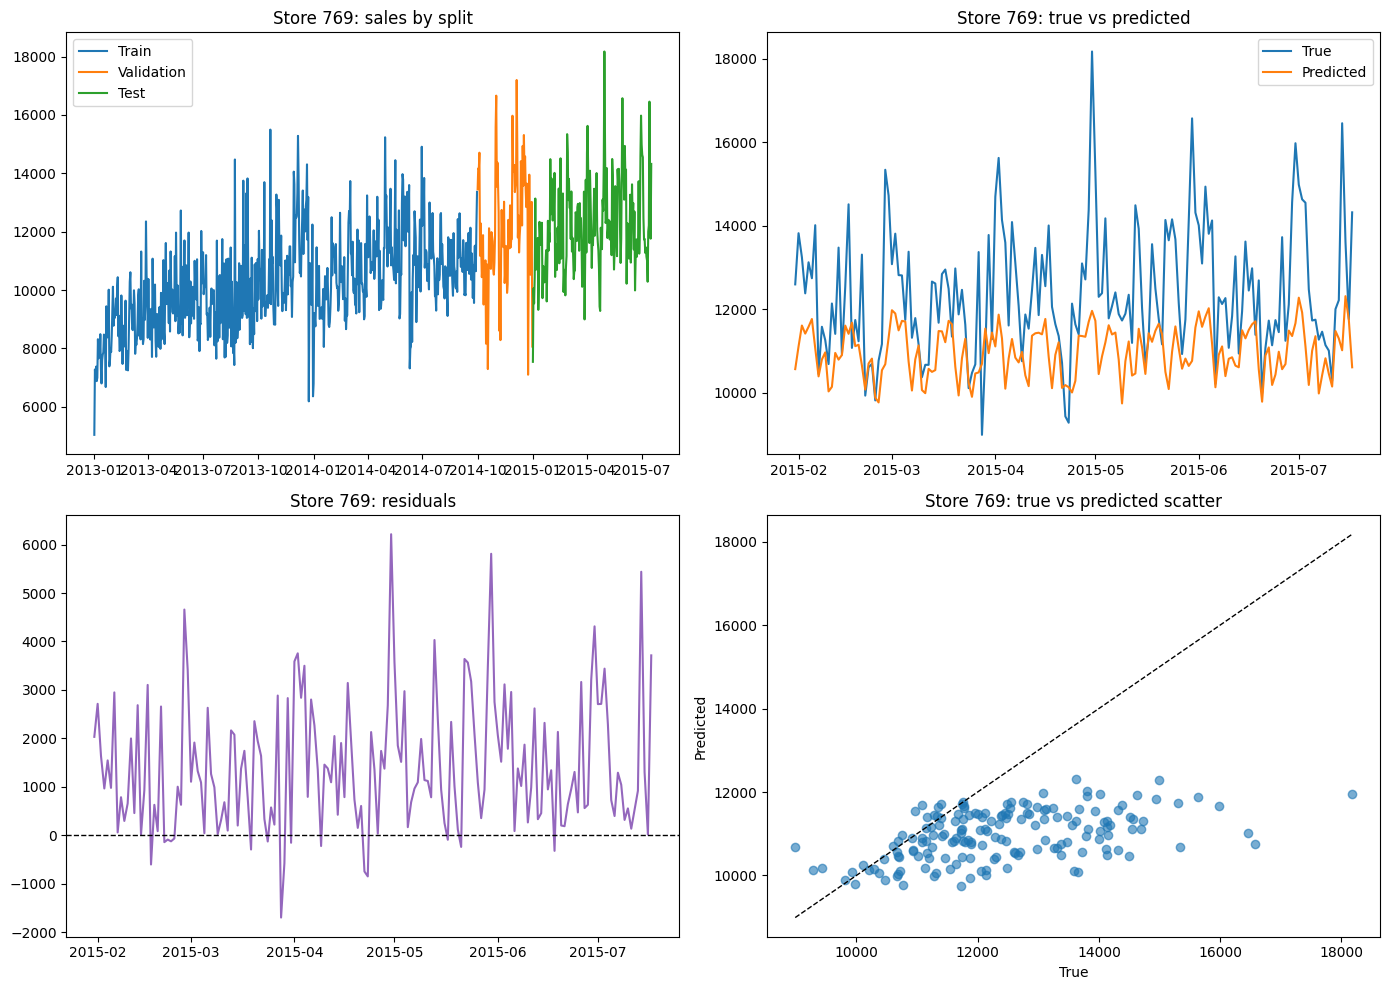

In [ ]:
from src.store_diagnostics import diagnose_store

store769 = diagnose_store(
    store_id=769,
    df_train=df_train,
    df_val=df_val,
    df_test=df_test,
    y_pred_norm=y_pred_norm,
    store_stats=store_stats,
    report_df=report_stores,
    target_stores=ev.TARGET_STORES,
    seq_len=SEQ_LEN,
)

## Interpretación 

El análisis específico de la tienda 769 muestra que el problema principal no parece ser un comportamiento aleatorio, sino un sesgo sistemático del modelo. Las predicciones se sitúan por debajo de las ventas reales durante casi todo el periodo de test, con un residuo medio positivo de aproximadamente 1500 ventas. Además, la desviación típica de las predicciones es mucho menor que la de los valores reales, lo que indica que el modelo genera predicciones demasiado conservadoras y no captura bien los picos de ventas.

También se observa un desplazamiento entre train y test: la media de ventas de la tienda 769 aumenta de forma notable en test respecto a train. Esto puede explicar que el modelo, entrenado con niveles de venta más bajos, tienda a infraestimar esta tienda. Por tanto, el problema no se solucionaría necesariamente añadiendo más variables lag o rolling, sino corrigiendo el sesgo de la tienda, añadiendo variables de tendencia/nivel reciente y probando mecanismos que permitan una adaptación más específica por tienda.

## 5 · Nuevas features

In [ ]:
# Features de tendencia / nivel reciente por tienda
# Se calculan sobre el dataframe global `df` ANTES del split temporal.
# Importante: cualquier feature basada en Sales usa shift(1) para evitar leakage.

required_cols = {"Store", "Date", "Sales"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise KeyError(f"Faltan columnas requeridas en df: {sorted(missing_cols)}")

# Trabajar sobre copia ordenada para asegurar consistencia temporal por tienda
df = df.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

# Lista de columnas nuevas a crear / sobrescribir
new_cols = [
    "days_since_start",
    "month_index",
    "week_index",
    "is_month_start",
    "is_month_end",
    "store_roll_30_sales",
    "store_roll_60_sales",
    "store_roll_90_sales",
    "store_roll_180_sales",
    "store_expanding_mean_sales",
    "store_roll_30_vs_90",
    "store_roll_90_vs_180",
    "store_recent_level_diff",
    "store_recent_level_pct_change",
]

existing_cols = [c for c in new_cols if c in df.columns]
if existing_cols:
    print(f"Sobrescribiendo columnas existentes de forma controlada: {existing_cols}")

# -------------------------------------------------------------------
# 1) Variables de tiempo global
# -------------------------------------------------------------------
first_date = df["Date"].min()

df["days_since_start"] = (df["Date"] - first_date).dt.days.astype("int32")
df["month_index"] = (df["Date"].dt.year * 12 + df["Date"].dt.month).astype("int32")
df["week_index"] = ((df["Date"] - first_date).dt.days // 7).astype("int32")
df["is_month_start"] = df["Date"].dt.is_month_start.astype("int8")
df["is_month_end"] = df["Date"].dt.is_month_end.astype("int8")

# -------------------------------------------------------------------
# 2) Variables de nivel reciente por tienda usando SOLO ventas pasadas
#    shift(1) evita usar la venta del día objetivo.
# -------------------------------------------------------------------
store_key = df["Store"]
sales_lag1 = df.groupby("Store")["Sales"].shift(1)

def _group_rolling_mean(lagged_sales, window):
    return (
        lagged_sales
        .groupby(store_key)
        .transform(lambda s: s.rolling(window=window, min_periods=1).mean())
        .astype("float32")
    )

df["store_roll_30_sales"] = _group_rolling_mean(sales_lag1, 30)
df["store_roll_60_sales"] = _group_rolling_mean(sales_lag1, 60)
df["store_roll_90_sales"] = _group_rolling_mean(sales_lag1, 90)
df["store_roll_180_sales"] = _group_rolling_mean(sales_lag1, 180)

df["store_expanding_mean_sales"] = (
    sales_lag1
    .groupby(store_key)
    .transform(lambda s: s.expanding(min_periods=1).mean())
    .astype("float32")
)

# -------------------------------------------------------------------
# 3) Variables de tendencia por tienda
#    Se protege contra divisiones por cero / infinitos.
# -------------------------------------------------------------------
eps = 1e-6

roll30 = df["store_roll_30_sales"].astype("float32")
roll90 = df["store_roll_90_sales"].astype("float32")
roll180 = df["store_roll_180_sales"].astype("float32")

den_90 = roll90.where(roll90.abs() > eps, np.nan)
den_180 = roll180.where(roll180.abs() > eps, np.nan)

df["store_roll_30_vs_90"] = (roll30 / den_90).astype("float32")
df["store_roll_90_vs_180"] = (roll90 / den_180).astype("float32")
df["store_recent_level_diff"] = (roll30 - roll180).astype("float32")
df["store_recent_level_pct_change"] = ((roll30 - roll180) / den_180).astype("float32")

# -------------------------------------------------------------------
# 4) Limpieza de infinitos y relleno de nulos con la mediana global
#    de cada columna nueva.
# -------------------------------------------------------------------
for col in new_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    median_value = df[col].median(skipna=True)
    if pd.isna(median_value):
        median_value = 0.0
    df[col] = df[col].fillna(median_value)

# Opcional: ajustar dtypes finales para no inflar memoria
float_cols = [
    "store_roll_30_sales",
    "store_roll_60_sales",
    "store_roll_90_sales",
    "store_roll_180_sales",
    "store_expanding_mean_sales",
    "store_roll_30_vs_90",
    "store_roll_90_vs_180",
    "store_recent_level_diff",
    "store_recent_level_pct_change",
]
df[float_cols] = df[float_cols].astype("float32")

# -------------------------------------------------------------------
# 5) Resumen / comprobaciones
# -------------------------------------------------------------------
print("Columnas nuevas creadas:")
print(new_cols)

display(df[new_cols].describe().T)

trend_check_cols = [
    "Date",
    "Store",
    "Sales",
    "store_roll_30_sales",
    "store_roll_60_sales",
    "store_roll_90_sales",
    "store_roll_180_sales",
    "store_expanding_mean_sales",
    "store_roll_30_vs_90",
    "store_roll_90_vs_180",
    "store_recent_level_diff",
    "store_recent_level_pct_change",
]

print("\nChequeo específico para la tienda 769 (últimas 20 filas):")
display(
    df.loc[df["Store"] == 769, trend_check_cols]
      .sort_values("Date")
      .tail(10)
)

Sobrescribiendo columnas existentes de forma controlada: ['days_since_start']
Columnas nuevas creadas:
['days_since_start', 'month_index', 'week_index', 'is_month_start', 'is_month_end', 'store_roll_30_sales', 'store_roll_60_sales', 'store_roll_90_sales', 'store_roll_180_sales', 'store_expanding_mean_sales', 'store_roll_30_vs_90', 'store_roll_90_vs_180', 'store_recent_level_diff', 'store_recent_level_pct_change']


,count,mean,std,min,25%,50%,75%,max
days_since_start,830918.0,457.460431,270.077571,0.000000,224.000000,447.000000,696.000000,927.000000
month_index,830918.0,24171.584095,8.883349,24157.000000,24164.000000,24171.000000,24179.000000,24187.000000
week_index,830918.0,64.971420,38.584490,0.000000,32.000000,63.000000,99.000000,132.000000
is_month_start,830918.0,0.023307,0.150876,0.000000,0.000000,0.000000,0.000000,1.000000
is_month_end,830918.0,0.032405,0.177074,0.000000,0.000000,0.000000,0.000000,1.000000
store_roll_30_sales,830918.0,6940.743652,2498.850586,1120.800049,5267.066895,6541.299805,8041.325073,26293.000000
store_roll_60_sales,830918.0,6925.524902,2470.117432,1120.800049,5268.649902,6541.583496,8010.000000,25594.632812
store_roll_90_sales,830918.0,6907.408691,2454.505127,1120.800049,5261.947144,6530.511230,7981.303589,25357.000000
store_roll_180_sales,830918.0,6873.507324,2440.763672,1120.800049,5242.270020,6513.816895,7931.386230,25357.000000
store_expanding_mean_sales,830918.0,6763.474121,2422.930420,1120.800049,5164.202515,6404.231445,7785.887329,25357.000000



Chequeo específico para la tienda 769 (últimas 20 filas):


,Date,Store,Sales,store_roll_30_sales,store_roll_60_sales,store_roll_90_sales,store_roll_180_sales,store_expanding_mean_sales,store_roll_30_vs_90,store_roll_90_vs_180,store_recent_level_diff,store_recent_level_pct_change
572703,2015-07-08,769,11463,12425.566406,12656.200195,12572.944336,12269.078125,10799.493164,0.988278,1.024767,156.488281,0.012755
572704,2015-07-09,769,11141,12403.433594,12651.733398,12580.799805,12267.294922,10800.215820,0.985902,1.025556,136.138672,0.011098
572705,2015-07-10,769,11010,12365.866211,12639.200195,12572.644531,12277.411133,10800.585938,0.983553,1.024047,88.455078,0.007205
572706,2015-07-11,769,10284,12363.633789,12616.900391,12566.789062,12281.977539,10800.813477,0.983834,1.023189,81.656250,0.006648
572707,2015-07-12,769,12004,12311.966797,12601.716797,12542.611328,12270.572266,10800.252930,0.981611,1.022170,41.394531,0.003373
572708,2015-07-13,769,12218,12269.833008,12560.250000,12526.299805,12271.377930,10801.556641,0.979526,1.020774,-1.544922,-0.000126
572709,2015-07-14,769,16458,12312.433594,12531.733398,12530.266602,12275.094727,10803.089844,0.982615,1.020788,37.338867,0.003042
572710,2015-07-15,769,13615,12462.633789,12605.500000,12565.322266,12300.783203,10809.203125,0.991828,1.021506,161.850586,0.013158
572711,2015-07-16,769,11760,12462.366211,12654.049805,12577.111328,12308.055664,10812.233398,0.990877,1.021860,154.310547,0.012537
572712,2015-07-17,769,14323,12439.366211,12661.183594,12552.133789,12319.383789,10813.255859,0.991016,1.018893,119.982422,0.009739


In [ ]:
# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Train: 577,527 | Val: 70,782 | Test: 182,609


In [ ]:
# Normalización por tienda — fit SOLO sobre df_train
store_stats = prep.build_store_normalizer(df_train)

df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)

## 6 · Entrenamiento del modelo y comprobaciones

In [ ]:
SEQ_LEN = 30

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"X_seq   train: {X_seq_tr.shape}    | dtype: {X_seq_tr.dtype}")
print(f"X_static train: {X_static_tr.shape} | dtype: {X_static_tr.dtype}")
print(f"y        train: {y_tr.shape}")

X_seq   train: (544077, 30, 11)    | dtype: float32
X_static train: (544077, 8) | dtype: float32
y        train: (544077,)


In [ ]:
tf.keras.backend.clear_session()

model = mdl.build_model(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_40 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_41 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_42 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_43 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store_enc       │ (None, 1, 16)     │     17,840 │ lambda_40[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType_enc   │ (None, 1, 2)      │          8 │ lambda_41[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment_enc  │ (None, 1, 2)      │          6 │ lambda_42[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval_… │ (None, 1, 2)      │          8 │ lambda_43[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_32          │ (None, 16)        │          0 │ emb_Store_enc[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_33          │ (None, 2)         │          0 │ emb_StoreType_en… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_34          │ (None, 2)         │          0 │ emb_Assortment_e… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_35          │ (None, 2)         │          0 │ emb_PromoInterva… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_44 (Lambda)  │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 26)        │          0 │ flatten_32[0][0], │
│ (Concatenate)       │                   │            │ flatten_33[0][0], │
│                     │                   │            │ flatten_34[0][0], │
│                     │                   │            │ flatten_35[0][0], │
│                     │                   │            │ lambda_44[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 64)        │          0 │ lstm[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = mdl.get_callbacks(
    checkpoint_path=os.path.join(OUTPUTS_DIR, "best_model.weights.h5")
)

history = mdl.train_model(
    model,
    X_train=(X_seq_tr, X_static_tr), y_train=y_tr,
    X_val=(X_seq_va, X_static_va),   y_val=y_va,
    callbacks=callbacks,
    epochs=100,
    batch_size=128,
)

Epoch 1/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7290

4251/4251 ━━━━━━━━━━━━━━━━━━━━ 52s 12ms/step - loss: 0.5293 - val_loss: 0.9852 - learning_rate: 0.0010
Epoch 2/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 49s 12ms/step - loss: 0.2882 - val_loss: 1.0818 - learning_rate: 0.0010
Epoch 3/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 49s 12ms/step - loss: 0.2574 - val_loss: 1.1238 - learning_rate: 0.0010
Epoch 4/100
4249/4251 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2487

4251/4251 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - loss: 0.2448 - val_loss: 0.8865 - learning_rate: 0.0010
Epoch 5/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - loss: 0.2351 - val_loss: 1.0094 - learning_rate: 0.0010
Epoch 6/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - loss: 0.2278 - val_loss: 1.1452 - learning_rate: 0.0010
Epoch 7/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - loss: 0.2216 - val_loss: 1.0653 - learning_rate: 0.0010
Epoch 8/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - loss: 0.2167 - val_loss: 1.2159 - learning_rate: 0.0010
Epoch 9/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - loss: 0.2139 - val_loss: 1.1313 - learning_rate: 0.0010
Epoch 10/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - loss: 0.2022 - val_loss: 1.2010 - learning_rate: 5.0000e-04
Epoch 11/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - loss: 0.2001 - val_loss: 1.0920 - learning_rate: 5.0000e-04
Epoch 12/100
4251/4251 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - loss: 0.1981 - val_los

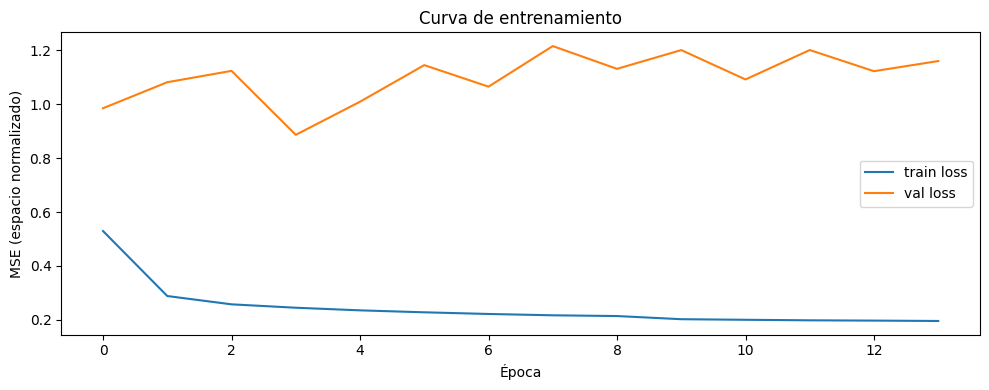

In [ ]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("MSE (espacio normalizado)")
plt.legend()
plt.title("Curva de entrenamiento")
plt.tight_layout()
plt.show()

In [ ]:
y_pred_norm = model.predict([X_seq_te, X_static_te], verbose=0).flatten()

In [ ]:
with redirect_stdout(io.StringIO()):
    report = ev.evaluation_report(df_test, y_pred_norm, store_stats)

report_stores = report[report["Store"] != "GLOBAL"].reset_index(drop=True)
global_row = report[report["Store"] == "GLOBAL"].reset_index(drop=True)

mean_row = pd.DataFrame([{
    "Store": "MEDIA",
    "n_samples": report_stores["n_samples"].mean(),
    "R2": report_stores["R2"].mean(),
    "mean_sales_true": report_stores["mean_sales_true"].mean(),
    "mean_sales_pred": report_stores["mean_sales_pred"].mean(),
}])

report_with_mean = pd.concat([report_stores, mean_row, global_row], ignore_index=True)
display(report_with_mean.round(4))

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133.0000,0.6194,4502.6992,4590.255371
1,2,134.0000,0.7171,4981.3881,4811.977539
2,3,133.0000,0.7959,6973.1429,6781.326172
3,4,134.0000,0.5551,9863.3134,9526.408203
4,5,134.0000,0.8368,4634.5522,4495.459473
5,562,168.0000,0.6791,18096.2738,17840.734375
6,682,168.0000,0.7105,11670.5179,11104.804688
7,733,168.0000,0.3667,15514.5298,15062.854492
8,769,168.0000,-0.5821,12410.4107,10986.470703
9,MEDIA,148.8889,0.5220,9849.6476,9466.699219


In [ ]:
raise SystemExit("Corta fuegos: parar aquí en Run All")

# Experimento 3

Se propone probar un modelo TCN (*Temporal Convolutional Network*) con embeddings como alternativa a la arquitectura LSTM many-to-one. Este tipo de red utiliza convoluciones temporales, lo que puede facilitar la captura de patrones locales, estacionalidad semanal y picos de ventas. Además, las TCN suelen presentar un entrenamiento más estable que las LSTM, por lo que pueden ser una opción interesante para comprobar si se mejora la predicción de las tiendas con peor rendimiento.

## 1 · Descarga de datos, preprocesado y partición para train, val y test

In [28]:
# Descarga de los datos

train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

# Partición temporal de los datos (definida en src.evaluate.py)

print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

# Preprocesado

# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)
Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]
Filas tras clean_train: 830,918  (eliminadas: 170,681)
Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
Columnas totales: 34
Train: 577,527 | Val: 70,782 | Test: 182,609


## 2 · Normalización

In [29]:
# Normalización por tienda — fit SOLO sobre df_train
store_stats = prep.build_store_normalizer(df_train)

df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)

## 3 · Modelo y entrenamiento 

In [30]:
SEQ_LEN = 30

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"X_seq   train: {X_seq_tr.shape}    | dtype: {X_seq_tr.dtype}")
print(f"X_static train: {X_static_tr.shape} | dtype: {X_static_tr.dtype}")
print(f"y        train: {y_tr.shape}")

X_seq   train: (544077, 30, 11)    | dtype: float32
X_static train: (544077, 8) | dtype: float32
y        train: (544077,)


In [31]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.backend.clear_session()

def residual_tcn_block(x, filters=64, kernel_size=3, dilation_rate=1, dropout=0.10):
    residual = x

    y = layers.Conv1D(
        filters,
        kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(x)
    y = layers.LayerNormalization()(y)
    y = layers.Activation("swish")(y)
    y = layers.SpatialDropout1D(dropout)(y)

    y = layers.Conv1D(
        filters,
        kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(y)
    y = layers.LayerNormalization()(y)

    if residual.shape[-1] != filters:
        residual = layers.Conv1D(filters, 1, padding="same")(residual)

    y = layers.Add()([residual, y])
    y = layers.Activation("swish")(y)

    return y


def build_tcn_model(X_seq_tr, X_static_tr, n_cat_features=4):
    seq_len = X_seq_tr.shape[1]
    n_seq_features = X_seq_tr.shape[2]
    n_static_features = X_static_tr.shape[1]
    n_num_features = n_static_features - n_cat_features

    # Entrada temporal
    seq_input = keras.Input(
        shape=(seq_len, n_seq_features),
        name="seq_input"
    )

    x = seq_input

    for dilation in [1, 2, 4, 8, 16]:
        x = residual_tcn_block(
            x,
            filters=64,
            kernel_size=3,
            dilation_rate=dilation,
            dropout=0.10
        )

    last_step = layers.Lambda(lambda t: t[:, -1, :])(x)
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)

    temporal_repr = layers.Concatenate()([
        last_step,
        avg_pool,
        max_pool
    ])

    # Entrada estática
    static_input = keras.Input(
        shape=(n_static_features,),
        name="static_input"
    )

    static_parts = []

    # Embeddings para categóricas
    for i in range(n_cat_features):
        vocab_size = int(np.nanmax(X_static_tr[:, i])) + 1

        emb_dim = 16 if i == 0 else 4  # Store más grande, resto más pequeño

        cat_i = layers.Lambda(
            lambda t, i=i: tf.cast(tf.round(t[:, i]), tf.int32)
        )(static_input)

        emb_i = layers.Embedding(
            input_dim=vocab_size,
            output_dim=emb_dim,
            name=f"embedding_cat_{i}"
        )(cat_i)

        static_parts.append(emb_i)

    # Numéricas estáticas
    if n_num_features > 0:
        static_num = layers.Lambda(
            lambda t: t[:, n_cat_features:]
        )(static_input)

        static_num = layers.LayerNormalization()(static_num)
        static_num = layers.Dense(32, activation="swish")(static_num)

        static_parts.append(static_num)

    static_repr = layers.Concatenate()(static_parts)
    static_repr = layers.Dense(64, activation="swish")(static_repr)
    static_repr = layers.Dropout(0.10)(static_repr)

    # Fusión
    z = layers.Concatenate()([
        temporal_repr,
        static_repr
    ])

    z = layers.Dense(128, activation="swish")(z)
    z = layers.Dropout(0.20)(z)
    z = layers.Dense(64, activation="swish")(z)
    z = layers.Dropout(0.10)(z)

    output = layers.Dense(1, name="output")(z)

    model = keras.Model(
        inputs=[seq_input, static_input],
        outputs=output,
        name="TCN_embeddings"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=3e-4,
            clipnorm=1.0
        ),
        loss="mse",
        metrics=["mse"]
    )

    return model


tcn_model = build_tcn_model(
    X_seq_tr,
    X_static_tr,
    n_cat_features=4
)

tcn_model.summary()

Model: "TCN_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 30, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      2,176 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 30, 64)    │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │     12,352 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │        768 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 30, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 30, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 30, 64)    │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 64)    │     12,352 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ activation_1[0][… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 30, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 178,565 (697.52 KB)

 Trainable params: 178,565 (697.52 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
callbacks = mdl.get_callbacks(
    checkpoint_path=os.path.join(OUTPUTS_DIR, "best_model.weights.h5")
)

history_tcn = tcn_model.fit(
    [X_seq_tr, X_static_tr],
    y_tr,
    validation_data=([X_seq_va, X_static_va], y_va),
    epochs=100,
    batch_size=64,
    shuffle=False,
    callbacks=callbacks
)

Epoch 1/100
8500/8502 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.7656 - mse: 7.7656

8502/8502 ━━━━━━━━━━━━━━━━━━━━ 216s 25ms/step - loss: 2.0040 - mse: 2.0040 - val_loss: 1.5740 - val_mse: 1.5740 - learning_rate: 3.0000e-04
Epoch 2/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 198s 23ms/step - loss: 0.7798 - mse: 0.7798 - val_loss: 6.0680 - val_mse: 6.0680 - learning_rate: 3.0000e-04
Epoch 3/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5181 - mse: 0.5181

8502/8502 ━━━━━━━━━━━━━━━━━━━━ 201s 23ms/step - loss: 0.4614 - mse: 0.4614 - val_loss: 1.0127 - val_mse: 1.0127 - learning_rate: 3.0000e-04
Epoch 4/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 196s 23ms/step - loss: 0.3196 - mse: 0.3196 - val_loss: 1.0395 - val_mse: 1.0395 - learning_rate: 3.0000e-04
Epoch 5/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2625 - mse: 0.2625

8502/8502 ━━━━━━━━━━━━━━━━━━━━ 206s 24ms/step - loss: 0.2570 - mse: 0.2570 - val_loss: 0.9152 - val_mse: 0.9152 - learning_rate: 3.0000e-04
Epoch 6/100
8501/8502 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2313 - mse: 0.2313

8502/8502 ━━━━━━━━━━━━━━━━━━━━ 227s 27ms/step - loss: 0.2295 - mse: 0.2295 - val_loss: 0.8984 - val_mse: 0.8984 - learning_rate: 3.0000e-04
Epoch 7/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 222s 26ms/step - loss: 0.2088 - mse: 0.2088 - val_loss: 1.0390 - val_mse: 1.0390 - learning_rate: 3.0000e-04
Epoch 8/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 224s 26ms/step - loss: 0.1993 - mse: 0.1993 - val_loss: 0.9942 - val_mse: 0.9942 - learning_rate: 3.0000e-04
Epoch 9/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 231s 27ms/step - loss: 0.1932 - mse: 0.1932 - val_loss: 1.0705 - val_mse: 1.0705 - learning_rate: 3.0000e-04
Epoch 10/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 232s 27ms/step - loss: 0.1892 - mse: 0.1892 - val_loss: 1.0322 - val_mse: 1.0322 - learning_rate: 3.0000e-04
Epoch 11/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 231s 27ms/step - loss: 0.1816 - mse: 0.1816 - val_loss: 1.3587 - val_mse: 1.3587 - learning_rate: 3.0000e-04
Epoch 12/100
8502/8502 ━━━━━━━━━━━━━━━━━━━━ 230s 27ms/step - loss: 0.1650 - mse: 0.1650 - val_loss

In [36]:
y_pred_norm = tcn_model.predict([X_seq_te, X_static_te], verbose=0).flatten()

In [37]:
import io
from contextlib import redirect_stdout

with redirect_stdout(io.StringIO()):
    report = ev.evaluation_report(df_test, y_pred_norm, store_stats)

report_stores = report[report["Store"] != "GLOBAL"].reset_index(drop=True)
global_row = report[report["Store"] == "GLOBAL"].reset_index(drop=True)

mean_row = pd.DataFrame([{
    "Store": "MEDIA",
    "n_samples": report_stores["n_samples"].mean(),
    "R2": report_stores["R2"].mean(),
    "mean_sales_true": report_stores["mean_sales_true"].mean(),
    "mean_sales_pred": report_stores["mean_sales_pred"].mean(),
}])

report_with_mean = pd.concat([report_stores, mean_row, global_row], ignore_index=True)
display(report_with_mean.round(4))

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133.0000,0.2502,4502.6992,4614.508301
1,2,134.0000,-0.6328,4981.3881,4661.219238
2,3,133.0000,-0.2942,6973.1429,6553.793457
3,4,134.0000,-0.7307,9863.3134,9205.177734
4,5,134.0000,-0.0880,4634.5522,4398.412109
5,562,168.0000,-1.0354,18096.2738,17434.158203
6,682,168.0000,-1.0790,11670.5179,10165.099609
7,733,168.0000,-1.4467,15514.5298,14710.281250
8,769,168.0000,-5.2300,12410.4107,10088.601562
9,MEDIA,148.8889,-1.1429,9849.6476,9092.362305


## Conclusiones del modelo TCN

En este experimento se ha probado una arquitectura TCN (*Temporal Convolutional Network*) con embeddings como alternativa al modelo LSTM many-to-one. La hipótesis inicial era que una red convolucional temporal podría capturar mejor patrones locales, estacionalidad semanal y picos de ventas que una LSTM.

Sin embargo, los resultados obtenidos no mejoran el modelo base. Aunque el R² global es positivo (`0.6590`), la media de R² por tienda es negativa (`-1.1429`). Esto indica que el buen resultado global está influido por la escala agregada de ventas, pero el modelo no está funcionando correctamente al analizar cada tienda de forma individual.

Además, la mayoría de tiendas presentan R² negativo, especialmente las tiendas 562, 682, 733 y 769. En el caso de la tienda 769, el resultado es especialmente malo (`R² = -5.2300`), lo que confirma que la TCN no consigue resolver el problema principal detectado previamente.

También se observa un patrón de infraestimación: en muchas tiendas, la media de ventas predicha es inferior a la media real. Por ejemplo, en la tienda 769 la media real es aproximadamente `12410`, mientras que la predicha es solo `10089`. Esto indica que el modelo genera predicciones demasiado conservadoras y no alcanza correctamente el nivel de ventas de las tiendas con valores más altos.

Por tanto, aunque la TCN era una alternativa razonable desde el punto de vista arquitectónico, en este experimento no ha conseguido mejorar la capacidad predictiva del modelo. Los resultados refuerzan la idea de que el problema no se soluciona simplemente cambiando la arquitectura temporal, sino que probablemente depende más del preprocesamiento, la función de pérdida, la calibración por tienda y la selección adecuada de variables.

In [153]:
raise SystemExit("Corta fuegos: parar aquí en Run All")

SystemExit: Corta fuegos: parar aquí en Run All

c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\Global\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Experimento 4

En este experimento no se busca entrenar una arquitectura nueva, sino comprobar si parte del error del modelo **E17** se debe a un **sesgo sistemático por tienda**. La idea es sencilla: si para una tienda concreta el modelo tiende a predecir siempre por debajo o por encima de las ventas reales, quizá pueda corregirse con un ajuste posterior sin cambiar la red neuronal.

Para ello, primero se reconstruye el modelo base tipo **E17** y se obtienen predicciones sobre **validación** y **test**. A continuación, usando **solo el split de validación**, se calcula para cada tienda el sesgo típico de sus errores, en este caso mediante la **mediana del residual** (`Sales - predicted_Sales`). Ese valor actúa como una corrección por tienda: si en validación una tienda quedó sistemáticamente infraestimada, en test se le suma ese ajuste a sus predicciones.

Por tanto, el objetivo real del experimento es evaluar si una **calibración externa por tienda**, aprendida únicamente con validación, puede mejorar el rendimiento del modelo original, especialmente en tiendas problemáticas como la **769**. Es un experimento de **postprocesado**, no de entrenamiento de un nuevo modelo, y sirve para comprobar si el problema principal es de arquitectura o más bien de **sesgo de nivel por tienda**.

In [54]:
import os
import io
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from contextlib import redirect_stdout

import src.preprocessing_dani as dani
import src.model as mdl

SEQ_LEN = 30
SEED = 42
E17_NAME = "e17_reproduction"

tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

In [55]:
# Descarga de los datos

train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

# Partición temporal de los datos (definida en src.evaluate.py)

print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

# Preprocesado

# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)
Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]
Filas tras clean_train: 830,918  (eliminadas: 170,681)
Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
Columnas totales: 34
Train: 577,527 | Val: 70,782 | Test: 182,609


In [56]:
# Ajuste SOLO con train
store_stats = prep.build_store_normalizer(df_train)

# Normalización de Sales usando SOLO stats de train
df_train_norm = prep.normalize_sales(df_train, store_stats)
df_val_norm   = prep.normalize_sales(df_val,   store_stats)
df_test_norm  = prep.normalize_sales(df_test,  store_stats)

# Lags y rolling
df_train_lag = dani.add_lag_and_rolling_features(df_train_norm)
df_val_lag   = dani.add_lag_and_rolling_features(df_val_norm)
df_test_lag  = dani.add_lag_and_rolling_features(df_test_norm)

# days_since_start pasa a rama estática, normalizado SOLO con train
dss_mean = float(df_train_lag["days_since_start"].mean())
dss_std  = max(float(df_train_lag["days_since_start"].std()), 1e-8)

df_train_e7 = dani.add_days_since_start_norm(df_train_lag, dss_mean, dss_std)
df_val_e7   = dani.add_days_since_start_norm(df_val_lag,   dss_mean, dss_std)
df_test_e7  = dani.add_days_since_start_norm(df_test_lag,  dss_mean, dss_std)

# Secuencias E17
X_seq_tr7, X_sta_tr7, y_tr7 = dani.build_sequences_ext3(df_train_e7, SEQ_LEN)
X_seq_va7, X_sta_va7, y_va7 = dani.build_sequences_ext3(df_val_e7,   SEQ_LEN)
X_seq_te7, X_sta_te7, y_te7 = dani.build_sequences_ext3(df_test_e7,  SEQ_LEN)

print(f"Train -> X_seq={X_seq_tr7.shape} | X_static={X_sta_tr7.shape} | y={y_tr7.shape}")
print(f"Val   -> X_seq={X_seq_va7.shape} | X_static={X_sta_va7.shape} | y={y_va7.shape}")
print(f"Test  -> X_seq={X_seq_te7.shape} | X_static={X_sta_te7.shape} | y={y_te7.shape}")

assert X_seq_tr7.shape[-1] == 13
assert X_sta_tr7.shape[-1] == 9
assert np.isfinite(X_seq_tr7).all() and np.isfinite(X_sta_tr7).all() and np.isfinite(y_tr7).all()
assert np.isfinite(X_seq_va7).all() and np.isfinite(X_sta_va7).all() and np.isfinite(y_va7).all()
assert np.isfinite(X_seq_te7).all() and np.isfinite(X_sta_te7).all() and np.isfinite(y_te7).all()

Train -> X_seq=(544077, 30, 13) | X_static=(544077, 9) | y=(544077,)
Val   -> X_seq=(42732, 30, 13) | X_static=(42732, 9) | y=(42732,)
Test  -> X_seq=(149159, 30, 13) | X_static=(149159, 9) | y=(149159,)


In [57]:
def extract_target_day_features(df, seq_len=SEQ_LEN):
    dow_parts, month_parts = [], []

    for _, grp in df.groupby("Store", sort=True):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len:
            continue

        target = grp.iloc[seq_len:]
        dow = (target["DayOfWeek"].to_numpy(dtype=np.int32) - 1).reshape(-1, 1)
        month = (target["Date"].dt.month.to_numpy(dtype=np.int32) - 1).reshape(-1, 1)

        dow_parts.append(dow)
        month_parts.append(month)

    return np.concatenate(dow_parts, axis=0), np.concatenate(month_parts, axis=0)

dow_tr7, month_tr7 = extract_target_day_features(df_train_e7, SEQ_LEN)
dow_va7, month_va7 = extract_target_day_features(df_val_e7,   SEQ_LEN)
dow_te7, month_te7 = extract_target_day_features(df_test_e7,  SEQ_LEN)

print(f"dow_tr7={dow_tr7.shape} | month_tr7={month_tr7.shape}")
print(f"dow_va7={dow_va7.shape} | month_va7={month_va7.shape}")
print(f"dow_te7={dow_te7.shape} | month_te7={month_te7.shape}")

assert dow_tr7.shape[0] == y_tr7.shape[0]
assert dow_va7.shape[0] == y_va7.shape[0]
assert dow_te7.shape[0] == y_te7.shape[0]

dow_tr7=(544077, 1) | month_tr7=(544077, 1)
dow_va7=(42732, 1) | month_va7=(42732, 1)
dow_te7=(149159, 1) | month_te7=(149159, 1)


In [58]:
def build_model_v2(
    n_stores,
    seq_len,
    n_seq_features,
    n_static_num_features,
    lstm_units=64,
    dense_branch_units=64,
    merge_units=128,
    dropout_rate=0.2,
    dow_emb_dim=4,
    month_emb_dim=4,
):
    emb_dims = getattr(
        mdl,
        "EMBEDDING_DIMS",
        {
            "Store_enc": 16,
            "StoreType_enc": 2,
            "Assortment_enc": 2,
            "PromoInterval_enc": 2,
        },
    )

    n_cat = len(prep.STATIC_CAT_COLS)

    seq_input = keras.Input(shape=(seq_len, n_seq_features), name="seq_input")
    static_input = keras.Input(shape=(n_cat + n_static_num_features,), name="static_input")
    dow_input = keras.Input(shape=(1,), dtype="int32", name="dow_input")
    month_input = keras.Input(shape=(1,), dtype="int32", name="month_input")

    x = layers.LSTM(lstm_units, name="lstm")(seq_input)
    x = layers.Dropout(dropout_rate)(x)
    seq_repr = layers.Dense(dense_branch_units, activation="relu")(x)

    cat_specs = [
        (0, n_stores, emb_dims["Store_enc"], "Store_enc"),
        (1, 4, emb_dims["StoreType_enc"], "StoreType_enc"),
        (2, 3, emb_dims["Assortment_enc"], "Assortment_enc"),
        (3, 4, emb_dims["PromoInterval_enc"], "PromoInterval_enc"),
    ]

    static_embs = []
    for i, vocab, dim, name in cat_specs:
        cat_i = layers.Lambda(lambda t, i=i: tf.cast(t[:, i:i+1], tf.int32))(static_input)
        emb_i = layers.Embedding(vocab, dim, name=f"emb_{name}")(cat_i)
        static_embs.append(layers.Flatten()(emb_i))

    static_num = layers.Lambda(lambda t: t[:, n_cat:])(static_input)

    static_repr = layers.Concatenate()(static_embs + [static_num])
    static_repr = layers.Dense(dense_branch_units, activation="relu")(static_repr)
    static_repr = layers.Dropout(dropout_rate)(static_repr)

    dow_repr = layers.Flatten()(layers.Embedding(7, dow_emb_dim, name="emb_dow")(dow_input))
    month_repr = layers.Flatten()(layers.Embedding(12, month_emb_dim, name="emb_month")(month_input))

    merged = layers.Concatenate()([seq_repr, static_repr, dow_repr, month_repr])
    merged = layers.Dense(merge_units, activation="relu")(merged)
    merged = layers.Dropout(dropout_rate)(merged)
    output = layers.Dense(1, activation="linear", name="output")(merged)

    return keras.Model(
        inputs=[seq_input, static_input, dow_input, month_input],
        outputs=output,
        name="model_e17_like",
    )

def make_callbacks(name, patience_reduce=3):
    checkpoint_path = os.path.join(OUTPUTS_DIR, f"{name}.weights.h5")
    return [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience_reduce,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

In [59]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

E17_CHECKPOINT = os.path.join(OUTPUTS_DIR, f"{E17_NAME}.weights.h5")

model_e17 = build_model_v2(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),
)

model_e17.compile(
    optimizer="adam",
    loss=keras.losses.Huber(delta=1.0),
)

if os.path.exists(E17_CHECKPOINT):
    model_e17.load_weights(E17_CHECKPOINT)
    print(f"Pesos cargados desde {E17_CHECKPOINT}")
else:
    h_e17 = model_e17.fit(
        [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7],
        y_tr7,
        validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
        epochs=20,
        batch_size=256,
        callbacks=make_callbacks(E17_NAME, patience_reduce=3),
        verbose=1,
    )
    model_e17.load_weights(E17_CHECKPOINT)
    print(f"Entrenado y recargado desde {E17_CHECKPOINT}")

Pesos cargados desde c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17_reproduction.weights.h5


c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\Global\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [60]:
y_pred_e17 = model_e17.predict(
    [X_seq_te7, X_sta_te7, dow_te7, month_te7],
    verbose=0
).flatten()

with redirect_stdout(io.StringIO()):
    rep_e17 = ev.evaluation_report(df_test_e7, y_pred_e17, store_stats)

display(rep_e17.round(4))
print(f"R2 medio tiendas: {rep_e17.loc[rep_e17['Store'].astype(str) != 'GLOBAL', 'R2'].mean():.4f}")

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.6429,4502.6992,4513.203125
1,2,134,0.7897,4981.3881,5108.434570
2,3,133,0.8557,6973.1429,7001.692871
3,4,134,0.5946,9863.3134,9710.114258
4,5,134,0.9058,4634.5522,4708.543945
5,562,168,0.7377,18096.2738,18231.968750
6,682,168,0.7544,11670.5179,11478.991211
7,733,168,0.4266,15514.5298,15491.910156
8,769,168,0.2332,12410.4107,11925.005859
9,GLOBAL,1340,0.9517,10319.9388,10257.907227


R2 medio tiendas: 0.6601


In [61]:
from src.store_diagnostics import build_prediction_frame

# Predicciones normalizadas de E17
y_pred_va_e17 = model_e17.predict(
    [X_seq_va7, X_sta_va7, dow_va7, month_va7],
    verbose=0
).flatten()

y_pred_te_e17 = model_e17.predict(
    [X_seq_te7, X_sta_te7, dow_te7, month_te7],
    verbose=0
).flatten()

# Pasar a escala real y alinear por fila
val_pred_e17 = build_prediction_frame(
    df_val_e7,
    y_pred_va_e17,
    store_stats,
    seq_len=SEQ_LEN,
)

test_pred_e17 = build_prediction_frame(
    df_test_e7,
    y_pred_te_e17,
    store_stats,
    seq_len=SEQ_LEN,
)

# IMPORTANTE:
# Esta calibración se aprende SOLO con validación.
# No se usa test para ajustar ningún parámetro.
store_bias = val_pred_e17.groupby("Store")["residual"].median()

bias_table = (
    val_pred_e17.groupby("Store")
    .agg(
        bias_median=("residual", "median"),
        n_val_samples=("residual", "size"),
    )
    .reset_index()
    .sort_values("bias_median", ascending=False)
    .reset_index(drop=True)
)

display(bias_table.round(4))
print("Bias tienda 769 en validación:")
display(bias_table[bias_table["Store"] == 769].round(4))

,Store,bias_median,n_val_samples
0,586,1371.4168,45
1,251,1266.5862,45
2,267,1214.0412,46
3,444,1161.3158,44
4,320,980.0189,46
...,...,...,...
930,506,-414.3771,45
931,928,-422.2383,45
932,749,-455.1853,45
933,1011,-502.6130,45


Bias tienda 769 en validación:


,Store,bias_median,n_val_samples
170,769,261.4413,62


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_pred_e17_cal = test_pred_e17.copy()
test_pred_e17_cal["store_bias"] = test_pred_e17_cal["Store"].map(store_bias).fillna(0.0)
test_pred_e17_cal["predicted_Sales_calibrated"] = (
    test_pred_e17_cal["predicted_Sales"] + test_pred_e17_cal["store_bias"]
).clip(lower=0)

def evaluate_prediction_frame(pred_df, pred_col):
    rows = []
    eval_df = pred_df[pred_df["Store"].isin(ev.TARGET_STORES)].copy()

    for store_id, grp in eval_df.groupby("Store", sort=True):
        y_true = grp["Sales"].to_numpy(dtype=float)
        y_pred = grp[pred_col].to_numpy(dtype=float)

        rows.append({
            "Store": store_id,
            "n_samples": len(grp),
            "R2": r2_score(y_true, y_pred),
            "mean_sales_true": y_true.mean(),
            "mean_sales_pred": y_pred.mean(),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        })

    y_true_all = eval_df["Sales"].to_numpy(dtype=float)
    y_pred_all = eval_df[pred_col].to_numpy(dtype=float)

    rows.append({
        "Store": "GLOBAL",
        "n_samples": len(eval_df),
        "R2": r2_score(y_true_all, y_pred_all),
        "mean_sales_true": y_true_all.mean(),
        "mean_sales_pred": y_pred_all.mean(),
        "MAE": mean_absolute_error(y_true_all, y_pred_all),
        "RMSE": np.sqrt(mean_squared_error(y_true_all, y_pred_all)),
    })

    return pd.DataFrame(rows)

In [63]:
rep_e17_real = evaluate_prediction_frame(test_pred_e17, "predicted_Sales")
rep_e17_calibrated = evaluate_prediction_frame(test_pred_e17_cal, "predicted_Sales_calibrated")

print("Antes de calibrar")
display(rep_e17_real.round(4))

print("Después de calibrar")
display(rep_e17_calibrated.round(4))

r2_mean_before = rep_e17_real.loc[rep_e17_real["Store"].astype(str) != "GLOBAL", "R2"].mean()
r2_mean_after  = rep_e17_calibrated.loc[rep_e17_calibrated["Store"].astype(str) != "GLOBAL", "R2"].mean()

r2_769_before = rep_e17_real.loc[rep_e17_real["Store"].astype(str) == "769", "R2"].iloc[0]
r2_769_after  = rep_e17_calibrated.loc[rep_e17_calibrated["Store"].astype(str) == "769", "R2"].iloc[0]

r2_global_before = rep_e17_real.loc[rep_e17_real["Store"].astype(str) == "GLOBAL", "R2"].iloc[0]
r2_global_after  = rep_e17_calibrated.loc[rep_e17_calibrated["Store"].astype(str) == "GLOBAL", "R2"].iloc[0]

print(f"R2 medio tiendas antes:   {r2_mean_before:.4f}")
print(f"R2 medio tiendas después: {r2_mean_after:.4f}")
print(f"R2 tienda 769 antes:      {r2_769_before:.4f}")
print(f"R2 tienda 769 después:    {r2_769_after:.4f}")
print(f"R2 GLOBAL antes:          {r2_global_before:.4f}")
print(f"R2 GLOBAL después:        {r2_global_after:.4f}")

comp_e17 = (
    rep_e17_real.rename(columns={
        "R2": "R2_before",
        "mean_sales_pred": "mean_pred_before",
        "mean_sales_true": "mean_true",
    })
    .merge(
        rep_e17_calibrated.rename(columns={
            "R2": "R2_after",
            "mean_sales_pred": "mean_pred_after",
        })[["Store", "R2_after", "mean_pred_after"]],
        on="Store",
        how="inner",
    )
)

comp_e17 = comp_e17[comp_e17["Store"].astype(str) != "GLOBAL"].copy()
comp_e17["delta_R2"] = comp_e17["R2_after"] - comp_e17["R2_before"]
comp_e17 = comp_e17[
    ["Store", "R2_before", "R2_after", "delta_R2", "mean_pred_before", "mean_pred_after", "mean_true"]
].sort_values("delta_R2", ascending=False).reset_index(drop=True)

display(comp_e17.round(4))
print("Fila tienda 769:")
display(comp_e17[comp_e17["Store"] == 769].round(4))

delta_mean_r2 = r2_mean_after - r2_mean_before
mean_769_before = float(comp_e17.loc[comp_e17["Store"] == 769, "mean_pred_before"].iloc[0])
mean_769_after = float(comp_e17.loc[comp_e17["Store"] == 769, "mean_pred_after"].iloc[0])
mean_769_true = float(comp_e17.loc[comp_e17["Store"] == 769, "mean_true"].iloc[0])

print("Conclusión automática — Experimento 17B")
if delta_mean_r2 > 0:
    print(f"- Mejora la media de R2 por tiendas ({r2_mean_before:.4f} -> {r2_mean_after:.4f}).")
    print("- La calibración ha reducido sesgos sistemáticos.")
else:
    print(f"- No mejora la media de R2 por tiendas ({r2_mean_before:.4f} -> {r2_mean_after:.4f}).")
    print("- El sesgo observado en validación no generaliza bien a test.")

if r2_769_after > r2_769_before:
    print(f"- La tienda 769 mejora ({r2_769_before:.4f} -> {r2_769_after:.4f}).")
    if mean_769_before < mean_769_true:
        print("- La calibración corrige parte de la infraestimación observada en 769.")
else:
    print(f"- La tienda 769 no mejora ({r2_769_before:.4f} -> {r2_769_after:.4f}).")

print(f"- Media predicha 769 antes/después/real: {mean_769_before:.2f} / {mean_769_after:.2f} / {mean_769_true:.2f}")

Antes de calibrar


,Store,n_samples,R2,mean_sales_true,mean_sales_pred,MAE,RMSE
0,1,133,0.6429,4502.6992,4513.2011,372.7609,498.7445
1,2,134,0.7897,4981.3881,5108.4355,523.5216,719.9956
2,3,133,0.8557,6973.1429,7001.6939,539.3358,753.8492
3,4,134,0.5946,9863.3134,9710.1164,764.4175,1208.4128
4,5,134,0.9058,4634.5522,4708.5445,356.0256,501.0132
5,562,168,0.7377,18096.2738,18231.9698,1022.6824,1378.8094
6,682,168,0.7544,11670.5179,11478.9959,1100.4594,1576.8009
7,733,168,0.4266,15514.5298,15491.9138,976.4051,1280.1499
8,769,168,0.2332,12410.4107,11925.0067,983.3868,1324.6899
9,GLOBAL,1340,0.9517,10319.9388,10257.9081,766.8157,1131.1894


Después de calibrar


,Store,n_samples,R2,mean_sales_true,mean_sales_pred,MAE,RMSE
0,1,133,0.4225,4502.6992,4894.6909,525.4311,634.2659
1,2,134,0.7803,4981.3881,5179.3748,546.7790,735.8338
2,3,133,0.8555,6973.1429,7014.1833,541.3320,754.4254
3,4,134,0.6010,9863.3134,9887.0555,786.7659,1198.8977
4,5,134,0.8992,4634.5522,4786.6396,382.2990,518.3337
5,562,168,0.7401,18096.2738,18134.9617,1014.2382,1372.6612
6,682,168,0.7455,11670.5179,12026.8179,1150.0266,1605.1698
7,733,168,0.3958,15514.5298,15811.9837,1032.7262,1314.0590
8,769,168,0.3142,12410.4107,12186.4481,935.6802,1252.7352
9,GLOBAL,1340,0.9511,10319.9388,10459.0352,795.5905,1137.3963


R2 medio tiendas antes:   0.6601
R2 medio tiendas después: 0.6393
R2 tienda 769 antes:      0.2332
R2 tienda 769 después:    0.3142
R2 GLOBAL antes:          0.9517
R2 GLOBAL después:        0.9511


,Store,R2_before,R2_after,delta_R2,mean_pred_before,mean_pred_after,mean_true
0,769,0.2332,0.3142,0.0810,11925.0067,12186.4481,12410.4107
1,4,0.5946,0.6010,0.0064,9710.1164,9887.0555,9863.3134
2,562,0.7377,0.7401,0.0023,18231.9698,18134.9617,18096.2738
3,3,0.8557,0.8555,-0.0002,7001.6939,7014.1833,6973.1429
4,5,0.9058,0.8992,-0.0066,4708.5445,4786.6396,4634.5522
5,682,0.7544,0.7455,-0.0089,11478.9959,12026.8179,11670.5179
6,2,0.7897,0.7803,-0.0094,5108.4355,5179.3748,4981.3881
7,733,0.4266,0.3958,-0.0308,15491.9138,15811.9837,15514.5298
8,1,0.6429,0.4225,-0.2204,4513.2011,4894.6909,4502.6992


Fila tienda 769:


,Store,R2_before,R2_after,delta_R2,mean_pred_before,mean_pred_after,mean_true
0,769,0.2332,0.3142,0.081,11925.0067,12186.4481,12410.4107


Conclusión automática — Experimento 17B
- No mejora la media de R2 por tiendas (0.6601 -> 0.6393).
- El sesgo observado en validación no generaliza bien a test.
- La tienda 769 mejora (0.2332 -> 0.3142).
- La calibración corrige parte de la infraestimación observada en 769.
- Media predicha 769 antes/después/real: 11925.01 / 12186.45 / 12410.41


In [ ]:
raise SystemExit("Corta fuegos: parar aquí en Run All")

# Experimento 5

A partir de la configuración tipo E17, inspirada en el mejor experimento de Óscar, se observa que la tienda 769 mejora notablemente respecto a los modelos anteriores, aunque todavía presenta cierta infraestimación. Posteriormente, el experimento de calibración simple muestra que una corrección de nivel puede mejorar el R² de esta tienda. Sin embargo, al aplicarse como postprocesado externo, dicha calibración empeora el rendimiento medio del conjunto.

Por este motivo, se propone integrar esta idea dentro de la propia arquitectura neuronal mediante una cabeza residual específica por tienda. Esta rama adicional aprende una corrección sobre la predicción base utilizando el embedding de la tienda y señales temporales como `days_since_start`, `DayOfWeek` y `Month`. De esta forma, la corrección se aprende durante el entrenamiento y la predicción final es generada directamente por el modelo, sin aplicar ajustes externos sobre el conjunto de test.

In [160]:
import os
import io
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from contextlib import redirect_stdout

import src.preprocessing_dani as dani
import src.model as mdl
import src.evaluate as ev

SEQ_LEN = 30
EXPERIMENT_NAME = "e17c_residual_head"
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("Determinismo activado.")
except Exception as e:
    print(f"No se pudo activar determinismo completo: {e}")

Determinismo activado.


In [161]:
# Descarga de los datos

train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

# Partición temporal de los datos (definida en src.evaluate.py)

print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

# Preprocesado

# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)
Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]
Filas tras clean_train: 830,918  (eliminadas: 170,681)
Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
Columnas totales: 34
Train: 577,527 | Val: 70,782 | Test: 182,609


In [162]:
required_globals = ["df_train", "df_val", "df_test", "prep", "ev"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Faltan variables requeridas en sesión: {missing_globals}")

if "store_stats" not in globals():
    store_stats = prep.build_store_normalizer(df_train)
    print("`store_stats` creado usando SOLO df_train.")
else:
    print("Reutilizando `store_stats` existente.")

def _ensure_sales_norm(df_split, split_name):
    if "Sales_norm" in df_split.columns:
        print(f"{split_name}: `Sales_norm` ya existe, se reutiliza.")
        return df_split.copy()
    out = prep.normalize_sales(df_split, store_stats)
    print(f"{split_name}: `Sales_norm` creado con stats de train.")
    return out

df_train_base = _ensure_sales_norm(df_train, "df_train")
df_val_base   = _ensure_sales_norm(df_val,   "df_val")
df_test_base  = _ensure_sales_norm(df_test,  "df_test")

df_train_lag = dani.add_lag_and_rolling_features(df_train_base)
df_val_lag   = dani.add_lag_and_rolling_features(df_val_base)
df_test_lag  = dani.add_lag_and_rolling_features(df_test_base)

dss_mean = float(df_train_lag["days_since_start"].mean())
dss_std  = max(float(df_train_lag["days_since_start"].std()), 1e-8)

df_train_e17c = dani.add_days_since_start_norm(df_train_lag, dss_mean, dss_std)
df_val_e17c   = dani.add_days_since_start_norm(df_val_lag,   dss_mean, dss_std)
df_test_e17c  = dani.add_days_since_start_norm(df_test_lag,  dss_mean, dss_std)

X_seq_tr7, X_sta_tr7, y_tr7 = dani.build_sequences_ext3(df_train_e17c, SEQ_LEN)
X_seq_va7, X_sta_va7, y_va7 = dani.build_sequences_ext3(df_val_e17c,   SEQ_LEN)
X_seq_te7, X_sta_te7, y_te7 = dani.build_sequences_ext3(df_test_e17c,  SEQ_LEN)

print(f"dss_mean={dss_mean:.4f} | dss_std={dss_std:.4f}")
print(f"Train -> X_seq={X_seq_tr7.shape} | X_static={X_sta_tr7.shape} | y={y_tr7.shape}")
print(f"Val   -> X_seq={X_seq_va7.shape} | X_static={X_sta_va7.shape} | y={y_va7.shape}")
print(f"Test  -> X_seq={X_seq_te7.shape} | X_static={X_sta_te7.shape} | y={y_te7.shape}")

assert X_seq_tr7.shape[-1] == 13, f"Se esperaban 13 features secuenciales, recibido {X_seq_tr7.shape[-1]}"
assert X_sta_tr7.shape[-1] == 9,  f"Se esperaban 9 features estáticas, recibido {X_sta_tr7.shape[-1]}"

arrays_to_check = {
    "X_seq_tr7": X_seq_tr7, "X_sta_tr7": X_sta_tr7, "y_tr7": y_tr7,
    "X_seq_va7": X_seq_va7, "X_sta_va7": X_sta_va7, "y_va7": y_va7,
    "X_seq_te7": X_seq_te7, "X_sta_te7": X_sta_te7, "y_te7": y_te7,
}
for name, arr in arrays_to_check.items():
    assert np.isfinite(arr).all(), f"{name} contiene NaN o infinitos"

print("OK -> Configuración E17/E17C lista.")

Reutilizando `store_stats` existente.
df_train: `Sales_norm` creado con stats de train.
df_val: `Sales_norm` creado con stats de train.
df_test: `Sales_norm` creado con stats de train.
dss_mean=312.4241 | dss_std=181.5569
Train -> X_seq=(544077, 30, 13) | X_static=(544077, 9) | y=(544077,)
Val   -> X_seq=(42732, 30, 13) | X_static=(42732, 9) | y=(42732,)
Test  -> X_seq=(149159, 30, 13) | X_static=(149159, 9) | y=(149159,)
OK -> Configuración E17/E17C lista.


In [163]:
def extract_target_day_features(df, seq_len=30):
    dow_parts, month_parts = [], []

    for _, grp in df.groupby("Store", sort=True):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len:
            continue

        target = grp.iloc[seq_len:]
        dow = (target["DayOfWeek"].to_numpy(dtype=np.int32) - 1).reshape(-1, 1)
        month = (target["Date"].dt.month.to_numpy(dtype=np.int32) - 1).reshape(-1, 1)

        dow_parts.append(dow)
        month_parts.append(month)

    if not dow_parts:
        raise ValueError("No se pudieron extraer features del día objetivo.")

    return np.concatenate(dow_parts, axis=0), np.concatenate(month_parts, axis=0)

dow_tr7, month_tr7 = extract_target_day_features(df_train_e17c, seq_len=SEQ_LEN)
dow_va7, month_va7 = extract_target_day_features(df_val_e17c,   seq_len=SEQ_LEN)
dow_te7, month_te7 = extract_target_day_features(df_test_e17c,  seq_len=SEQ_LEN)

for split_name, dow, month, y in [
    ("train", dow_tr7, month_tr7, y_tr7),
    ("val",   dow_va7, month_va7, y_va7),
    ("test",  dow_te7, month_te7, y_te7),
]:
    assert len(dow) == len(y),   f"{split_name}: dow no alinea con y"
    assert len(month) == len(y), f"{split_name}: month no alinea con y"
    print(
        f"{split_name}: "
        f"dow_shape={dow.shape}, month_shape={month.shape}, "
        f"dow_range=({dow.min()}, {dow.max()}), "
        f"month_range=({month.min()}, {month.max()})"
    )

print("OK -> DayOfWeek y Month alineados con build_sequences_ext3.")

train: dow_shape=(544077, 1), month_shape=(544077, 1), dow_range=(0, 6), month_range=(0, 11)
val: dow_shape=(42732, 1), month_shape=(42732, 1), dow_range=(0, 6), month_range=(9, 11)
test: dow_shape=(149159, 1), month_shape=(149159, 1), dow_range=(0, 6), month_range=(0, 6)
OK -> DayOfWeek y Month alineados con build_sequences_ext3.


In [164]:
def build_model_v3_residual(
    n_stores,
    seq_len,
    n_seq_features,
    n_static_num_features,
    store_embedding_dim=16,
    lstm_units=64,
    dense_units=64,
    merge_units=128,
    dropout_rate=0.2,
    residual_units=16,
    residual_dropout=0.1,
):
    seq_input = keras.Input(shape=(seq_len, n_seq_features), name="seq")
    static_input = keras.Input(shape=(4 + n_static_num_features,), name="static")
    dow_input = keras.Input(shape=(1,), dtype="int32", name="dow")
    month_input = keras.Input(shape=(1,), dtype="int32", name="month")

    # Rama secuencial
    seq_features = layers.LSTM(lstm_units, name="seq_lstm")(seq_input)
    seq_features = layers.Dropout(dropout_rate, name="seq_dropout")(seq_features)
    seq_features = layers.Dense(dense_units, activation="relu", name="seq_dense")(seq_features)

    # Categóricas estáticas
    store_idx = keras.ops.cast(static_input[:, 0:1], "int32")
    store_type_idx = keras.ops.cast(static_input[:, 1:2], "int32")
    assortment_idx = keras.ops.cast(static_input[:, 2:3], "int32")
    promo_interval_idx = keras.ops.cast(static_input[:, 3:4], "int32")

    store_emb = layers.Embedding(
        input_dim=n_stores,
        output_dim=store_embedding_dim,
        name="emb_store"
    )(store_idx)
    store_emb_flat = layers.Flatten(name="store_emb_flat")(store_emb)

    store_type_emb_flat = layers.Flatten(name="store_type_emb_flat")(
        layers.Embedding(input_dim=4, output_dim=2, name="emb_storetype")(store_type_idx)
    )
    assortment_emb_flat = layers.Flatten(name="assortment_emb_flat")(
        layers.Embedding(input_dim=3, output_dim=2, name="emb_assortment")(assortment_idx)
    )
    promo_interval_emb_flat = layers.Flatten(name="promo_interval_emb_flat")(
        layers.Embedding(input_dim=4, output_dim=2, name="emb_promointerval")(promo_interval_idx)
    )

    num_feats = static_input[:, 4:]

    static_features = layers.Concatenate(name="static_concat")([
        store_emb_flat,
        store_type_emb_flat,
        assortment_emb_flat,
        promo_interval_emb_flat,
        num_feats,
    ])
    static_features = layers.Dense(dense_units, activation="relu", name="static_dense")(static_features)
    static_features = layers.Dropout(dropout_rate, name="static_dropout")(static_features)

    # Embeddings del día objetivo
    dow_emb_flat = layers.Flatten(name="dow_emb_flat")(
        layers.Embedding(input_dim=7, output_dim=4, name="emb_dayofweek")(dow_input)
    )
    month_emb_flat = layers.Flatten(name="month_emb_flat")(
        layers.Embedding(input_dim=12, output_dim=4, name="emb_month")(month_input)
    )

    # Predicción base estilo E17
    base_features = layers.Concatenate(name="base_concat")([
        seq_features,
        static_features,
        dow_emb_flat,
        month_emb_flat,
    ])
    base_features = layers.Dense(merge_units, activation="relu", name="base_merge_dense")(base_features)
    base_features = layers.Dropout(dropout_rate, name="base_merge_dropout")(base_features)
    base_features = layers.Dense(64, activation="relu", name="base_hidden")(base_features)
    base_output = layers.Dense(1, activation="linear", name="base_output")(base_features)

    # Cabeza residual aprendida por tienda
    residual_input = layers.Concatenate(name="residual_concat")([
        store_emb_flat,
        num_feats,
        dow_emb_flat,
        month_emb_flat,
    ])
    r = layers.Dense(residual_units, activation="relu", name="residual_dense")(residual_input)
    r = layers.Dropout(residual_dropout, name="residual_dropout")(r)
    residual_output = layers.Dense(
        1,
        activation="linear",
        kernel_initializer="zeros",
        bias_initializer="zeros",
        name="store_residual_output",
    )(r)

    final_output = layers.Add(name="final_output")([base_output, residual_output])

    model = keras.Model(
        inputs=[seq_input, static_input, dow_input, month_input],
        outputs=final_output,
        name="E17C_residual_head",
    )
    return model

In [165]:
def make_callbacks(name, patience_reduce=3):
    os.makedirs(OUTPUTS_DIR, exist_ok=True)
    checkpoint_path = os.path.join(OUTPUTS_DIR, f"{name}.keras")

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience_reduce,
            min_lr=1e-6,
            verbose=1,
        ),
    ]
    return callbacks, checkpoint_path

In [166]:
tf.keras.backend.clear_session()
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

model_e17c = build_model_v3_residual(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),
)

model_e17c.summary()

model_e17c.compile(
    optimizer="adam",
    loss=keras.losses.Huber(delta=1.0),
    metrics=["mse"],
)

callbacks_e17c, ckpt_e17c = make_callbacks(
    EXPERIMENT_NAME,
    patience_reduce=3,
)

h_e17c = model_e17c.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7],
    y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=20,
    batch_size=256,
    callbacks=callbacks_e17c,
    verbose=1,
)

if os.path.exists(ckpt_e17c):
    try:
        model_e17c = keras.models.load_model(ckpt_e17c)
        print(f"Mejor modelo cargado desde: {ckpt_e17c}")
    except Exception as e:
        print(f"No se pudo recargar el checkpoint `.keras`; se mantienen los pesos actuales. Detalle: {e}")
else:
    print("No se encontró checkpoint; se mantienen los pesos actuales.")

Model: "E17C_residual_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 1)         │          0 │ static[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 1)         │          0 │ static[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 1)         │          0 │ static[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 1)         │          0 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 1)         │          0 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_2 (Cast)       │ (None, 1)         │          0 │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_3 (Cast)       │ (None, 1)         │          0 │ get_item_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_store           │ (None, 1, 16)     │     17,840 │ cast[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_storetype       │ (None, 1, 2)      │          8 │ cast_1[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_assortment      │ (None, 1, 2)      │          6 │ cast_2[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_promointerval   │ (None, 1, 2)      │          8 │ cast_3[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 13)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_emb_flat      │ (None, 16)        │          0 │ emb_store[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_type_emb_flat │ (None, 2)         │          0 │ emb_storetype[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assortment_emb_flat │ (None, 2)         │          0 │ emb_assortment[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ promo_interval_emb… │ (None, 2)         │          0 │ emb_promointerva… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 5)         │          0 │ static[0][0]      │
│ (GetItem)           │                   │            │                 

 Total params: 70,212 (274.27 KB)

 Trainable params: 70,212 (274.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2124/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1792 - mse: 0.4090
Epoch 1: val_loss improved from None to 0.27964, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17c_residual_head.keras

Epoch 1: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17c_residual_head.keras
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - loss: 0.1259 - mse: 0.2817 - val_loss: 0.2796 - val_mse: 0.6958 - learning_rate: 0.0010
Epoch 2/20
2124/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0845 - mse: 0.1861
Epoch 2: val_loss improved from 0.27964 to 0.26579, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17c_residual_head.keras

Epoch 2: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17c_residual_head.keras
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/st

In [167]:
y_pred_e17c = model_e17c.predict(
    [X_seq_te7, X_sta_te7, dow_te7, month_te7],
    verbose=0
).flatten()

with redirect_stdout(io.StringIO()):
    rep_e17c = ev.evaluation_report(df_test_e17c, y_pred_e17c, store_stats)

display(rep_e17c.round(4))

r2_mean_e17c = rep_e17c.loc[rep_e17c["Store"].astype(str) != "GLOBAL", "R2"].mean()
r2_global_e17c = rep_e17c.loc[rep_e17c["Store"].astype(str) == "GLOBAL", "R2"].iloc[0]

row_769_e17c = rep_e17c.loc[rep_e17c["Store"].astype(str) == "769"].copy()
if row_769_e17c.empty:
    raise ValueError("No se encontró la tienda 769 en `rep_e17c`.")
row_769_e17c = row_769_e17c.iloc[0]

r2_769_e17c = row_769_e17c["R2"]

print(f"R2 medio tiendas: {r2_mean_e17c:.4f}")
print(f"R2 GLOBAL:        {r2_global_e17c:.4f}")
print(f"R2 tienda 769:    {r2_769_e17c:.4f}")
print(f"mean_sales_true 769: {row_769_e17c['mean_sales_true']:.2f}")
print(f"mean_sales_pred 769: {row_769_e17c['mean_sales_pred']:.2f}")

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.5749,4502.6992,4696.630859
1,2,134,0.7296,4981.3881,5209.177246
2,3,133,0.7517,6973.1429,7232.695312
3,4,134,0.6032,9863.3134,10090.264648
4,5,134,0.8779,4634.5522,4826.989258
5,562,168,0.7009,18096.2738,18393.921875
6,682,168,0.7938,11670.5179,11673.460938
7,733,168,0.4473,15514.5298,15733.068359
8,769,168,0.3370,12410.4107,12114.330078
9,GLOBAL,1340,0.9512,10319.9388,10457.630859


R2 medio tiendas: 0.6462
R2 GLOBAL:        0.9512
R2 tienda 769:    0.3370
mean_sales_true 769: 12410.41
mean_sales_pred 769: 12114.33


In [168]:
from src.store_diagnostics import build_prediction_frame

pred_e17c = build_prediction_frame(
    df_test_e17c,
    y_pred_e17c,
    store_stats,
    seq_len=SEQ_LEN,
)

pred_769_e17c = pred_e17c[pred_e17c["Store"] == 769].sort_values("Date").reset_index(drop=True)
if pred_769_e17c.empty:
    raise ValueError("No hay filas para la tienda 769 en `pred_e17c`.")

display(pred_769_e17c.head(5))

display(
    pred_769_e17c[["Sales", "predicted_Sales", "residual", "abs_error", "pct_error"]]
    .describe()
    .round(4)
)

print(f"Media real 769:      {pred_769_e17c['Sales'].mean():.2f}")
print(f"Media predicha 769:  {pred_769_e17c['predicted_Sales'].mean():.2f}")
print(f"Residual medio 769:  {pred_769_e17c['residual'].mean():.2f}")
print(f"Residual mediano 769:{pred_769_e17c['residual'].median():.2f}")

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,...,CompetitionDistance_norm,Sales_norm,Sales_lag_7,Sales_lag_14,Sales_roll_28,days_since_start_norm,predicted_Sales,residual,abs_error,pct_error
0,769,6,2015-01-31,12597,3502,1,0,0,0,109412,...,-0.189698,1.437784,-0.304997,-0.230407,-0.119061,2.465209,11242.549165,1354.450835,1354.450835,10.752170
1,769,7,2015-02-01,13823,2954,1,0,0,0,206705,...,-0.189698,2.035599,0.470297,0.460194,0.366752,2.470717,11574.340698,2248.659302,2248.659302,16.267520
2,769,1,2015-02-02,13249,3600,1,1,0,0,320011,...,-0.189698,1.762604,1.322296,0.390828,-0.117026,2.476225,12818.828167,430.171833,430.171833,3.246825
3,769,2,2015-02-03,12382,3435,1,1,0,0,540149,...,-0.189698,1.326976,0.764546,0.116940,-0.021720,2.481733,11194.573662,1187.426338,1187.426338,9.589940
4,769,3,2015-02-04,13126,3838,1,1,0,0,731347,...,-0.189698,1.702568,1.104852,0.310365,0.024561,2.487241,12073.655979,1052.344021,1052.344021,8.017248


,Sales,predicted_Sales,residual,abs_error,pct_error
count,168.0000,168.0000,168.0000,168.0000,168.0000
mean,12410.4107,12114.3317,296.0790,879.3168,1.5162
std,1517.3037,893.1368,1199.2360,865.1744,9.0654
min,8992.0000,10051.6035,-2520.6545,1.4132,-26.7188
25%,11328.5000,11498.1384,-440.1908,288.3138,-3.8891
50%,12137.5000,12014.7873,200.1176,612.4740,1.5976
75%,13473.5000,12793.8885,897.7397,1206.5188,6.5807
max,18177.0000,14295.8636,5324.0362,5324.0362,32.1209


Media real 769:      12410.41
Media predicha 769:  12114.33
Residual medio 769:  296.08
Residual mediano 769:200.12


In [171]:
print("Conclusión automática — E5")

if "rep_e17_reference" in globals() and rep_e17_reference is not None:
    rep_prev = rep_e17_reference.copy()
    rep_prev = rep_prev[rep_prev["Store"].astype(str) != "MEDIA"].copy()

    r2_mean_prev = rep_prev.loc[rep_prev["Store"].astype(str) != "GLOBAL", "R2"].mean()
    r2_mean_cur = rep_e17c.loc[rep_e17c["Store"].astype(str) != "GLOBAL", "R2"].mean()

    row_769_prev = rep_prev.loc[rep_prev["Store"].astype(str) == "769"]
    row_769_cur = rep_e17c.loc[rep_e17c["Store"].astype(str) == "769"]

    if not row_769_prev.empty and not row_769_cur.empty:
        r2_769_prev = row_769_prev["R2"].iloc[0]
        r2_769_cur = row_769_cur["R2"].iloc[0]
        mean_pred_769_prev = row_769_prev["mean_sales_pred"].iloc[0]
        mean_pred_769_cur = row_769_cur["mean_sales_pred"].iloc[0]
        mean_true_769_cur = row_769_cur["mean_sales_true"].iloc[0]

        if r2_mean_cur > r2_mean_prev and r2_769_cur > r2_769_prev:
            print("- La cabeza residual ayuda globalmente y también mejora la tienda 769.")
            print("- La rama residual aprendida reduce parte del sesgo específico de esa tienda.")
        elif r2_mean_cur <= r2_mean_prev and r2_769_cur > r2_769_prev:
            print("- La rama residual mejora la tienda 769, pero no mejora la media global.")
            print("- Esto sugiere que aprende correcciones útiles para la tienda problemática, pero puede introducir sobreajuste o perjudicar otras tiendas.")
        elif r2_mean_cur > r2_mean_prev and r2_769_cur <= r2_769_prev:
            print("- La cabeza residual ayuda globalmente, aunque no mejora la tienda 769.")
        else:
            print("- No se observa mejora clara frente a E17.")
            print("- Esto sugiere que la arquitectura E17 ya captura la mayor parte de la señal y que la rama residual no aporta mejora clara.")

        print(f"- R2 medio antes/después: {r2_mean_prev:.4f} -> {r2_mean_cur:.4f}")
        print(f"- R2 769 antes/después:   {r2_769_prev:.4f} -> {r2_769_cur:.4f}")
        print(f"- mean_pred 769 antes/después: {mean_pred_769_prev:.2f} -> {mean_pred_769_cur:.2f}")
        print(f"- mean_true 769 actual:       {mean_true_769_cur:.2f}")
    else:
        print("- No se ha podido comparar la tienda 769 con un reporte previo de E17.")
else:
    print("- No se encontró un reporte previo de E17 para comparar.")
    print("- Se muestra solo el rendimiento de E17C.")
    print(f"- R2 medio E5: {r2_mean_e17c:.4f}")
    print(f"- R2 GLOBAL E5: {r2_global_e17c:.4f}")
    print(f"- R2 tienda 769 E5: {r2_769_e17c:.4f}")

Conclusión automática — E5
- No se encontró un reporte previo de E17 para comparar.
- Se muestra solo el rendimiento de E17C.
- R2 medio E5: 0.6462
- R2 GLOBAL E5: 0.9512
- R2 tienda 769 E5: 0.3370


In [170]:
raise SystemExit("Corta fuegos: parar aquí en Run All")

SystemExit: Corta fuegos: parar aquí en Run All

c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\Global\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Experimeto 6

El experimento 5 muestra que añadir una cabeza residual aprendida mejora la tienda 769, pero reduce ligeramente el R² medio. Esto sugiere que la corrección residual es útil para las tiendas problemáticas, pero puede perjudicar a tiendas que el modelo base ya predecía correctamente.

Por ello, se plantea un nuevo experimento 5 con una cabeza residual selectiva. En este caso, la predicción final se define como la predicción base más una corrección residual únicamente para las tiendas identificadas como problemáticas en validación. Para el resto de tiendas, la salida del modelo se mantiene igual que la predicción base. De esta forma, se intenta conservar el buen rendimiento global del modelo E17 de mi compañero Oscar y aplicar capacidad adicional solo donde es necesaria.

In [ ]:
import os
import io
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from contextlib import redirect_stdout

import src.preprocessing_dani as dani
import src.model as mdl
import src.evaluate as ev

SEQ_LEN = 30
EXPERIMENT_NAME = "e17d_selective_residual_head"
SEED = 42
RESIDUAL_STORES = [733, 769]

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("Determinismo activado.")
except Exception as e:
    print(f"No se pudo activar determinismo completo: {e}")

Determinismo activado.


In [ ]:
# Descarga de los datos

train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

# Partición temporal de los datos (definida en src.evaluate.py)

print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

# Preprocesado

# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)
Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]
Filas tras clean_train: 830,918  (eliminadas: 170,681)
Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
Columnas totales: 34
Train: 577,527 | Val: 70,782 | Test: 182,609


In [ ]:
required_globals = ["df_train", "df_val", "df_test", "prep", "ev"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise NameError(f"Faltan variables requeridas en sesión: {missing_globals}")

if "store_stats" not in globals():
    store_stats = prep.build_store_normalizer(df_train)
    print("`store_stats` creado usando SOLO df_train.")
else:
    print("Reutilizando `store_stats` existente.")

def _ensure_sales_norm(df_split, split_name):
    if "Sales_norm" in df_split.columns:
        print(f"{split_name}: `Sales_norm` ya existe, se reutiliza.")
        return df_split.copy()
    out = prep.normalize_sales(df_split, store_stats)
    print(f"{split_name}: `Sales_norm` creado con stats de train.")
    return out

df_train_base = _ensure_sales_norm(df_train, "df_train")
df_val_base   = _ensure_sales_norm(df_val,   "df_val")
df_test_base  = _ensure_sales_norm(df_test,  "df_test")

df_train_lag = dani.add_lag_and_rolling_features(df_train_base)
df_val_lag   = dani.add_lag_and_rolling_features(df_val_base)
df_test_lag  = dani.add_lag_and_rolling_features(df_test_base)

dss_mean = float(df_train_lag["days_since_start"].mean())
dss_std  = max(float(df_train_lag["days_since_start"].std()), 1e-8)

df_train_e17d = dani.add_days_since_start_norm(df_train_lag, dss_mean, dss_std)
df_val_e17d   = dani.add_days_since_start_norm(df_val_lag,   dss_mean, dss_std)
df_test_e17d  = dani.add_days_since_start_norm(df_test_lag,  dss_mean, dss_std)

X_seq_tr7, X_sta_tr7, y_tr7 = dani.build_sequences_ext3(df_train_e17d, SEQ_LEN)
X_seq_va7, X_sta_va7, y_va7 = dani.build_sequences_ext3(df_val_e17d,   SEQ_LEN)
X_seq_te7, X_sta_te7, y_te7 = dani.build_sequences_ext3(df_test_e17d,  SEQ_LEN)

print(f"dss_mean={dss_mean:.4f} | dss_std={dss_std:.4f}")
print(f"Train -> X_seq={X_seq_tr7.shape} | X_static={X_sta_tr7.shape} | y={y_tr7.shape}")
print(f"Val   -> X_seq={X_seq_va7.shape} | X_static={X_sta_va7.shape} | y={y_va7.shape}")
print(f"Test  -> X_seq={X_seq_te7.shape} | X_static={X_sta_te7.shape} | y={y_te7.shape}")

assert X_seq_tr7.shape[-1] == 13, f"Se esperaban 13 features secuenciales, recibido {X_seq_tr7.shape[-1]}"
assert X_sta_tr7.shape[-1] == 9,  f"Se esperaban 9 features estáticas, recibido {X_sta_tr7.shape[-1]}"

arrays_to_check = {
    "X_seq_tr7": X_seq_tr7, "X_sta_tr7": X_sta_tr7, "y_tr7": y_tr7,
    "X_seq_va7": X_seq_va7, "X_sta_va7": X_sta_va7, "y_va7": y_va7,
    "X_seq_te7": X_seq_te7, "X_sta_te7": X_sta_te7, "y_te7": y_te7,
}
for name, arr in arrays_to_check.items():
    assert np.isfinite(arr).all(), f"{name} contiene NaN o infinitos"

print("OK -> Configuración E17/E17D lista.")

`store_stats` creado usando SOLO df_train.
df_train: `Sales_norm` creado con stats de train.
df_val: `Sales_norm` creado con stats de train.
df_test: `Sales_norm` creado con stats de train.
dss_mean=312.4241 | dss_std=181.5569
Train -> X_seq=(544077, 30, 13) | X_static=(544077, 9) | y=(544077,)
Val   -> X_seq=(42732, 30, 13) | X_static=(42732, 9) | y=(42732,)
Test  -> X_seq=(149159, 30, 13) | X_static=(149159, 9) | y=(149159,)
OK -> Configuración E17/E17D lista.


In [ ]:
def extract_target_day_features(df, seq_len=30):
    dow_parts, month_parts = [], []

    for _, grp in df.groupby("Store", sort=True):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len:
            continue

        target = grp.iloc[seq_len:]
        dow = (target["DayOfWeek"].to_numpy(dtype=np.int32) - 1).reshape(-1, 1)
        month = (target["Date"].dt.month.to_numpy(dtype=np.int32) - 1).reshape(-1, 1)

        dow_parts.append(dow)
        month_parts.append(month)

    if not dow_parts:
        raise ValueError("No se pudieron extraer features del día objetivo.")

    return np.concatenate(dow_parts, axis=0), np.concatenate(month_parts, axis=0)

dow_tr7, month_tr7 = extract_target_day_features(df_train_e17d, seq_len=SEQ_LEN)
dow_va7, month_va7 = extract_target_day_features(df_val_e17d,   seq_len=SEQ_LEN)
dow_te7, month_te7 = extract_target_day_features(df_test_e17d,  seq_len=SEQ_LEN)

for split_name, dow, month, y in [
    ("train", dow_tr7, month_tr7, y_tr7),
    ("val",   dow_va7, month_va7, y_va7),
    ("test",  dow_te7, month_te7, y_te7),
]:
    assert len(dow) == len(y),   f"{split_name}: dow no alinea con y"
    assert len(month) == len(y), f"{split_name}: month no alinea con y"
    print(
        f"{split_name}: "
        f"dow_shape={dow.shape}, month_shape={month.shape}, "
        f"dow_range=({dow.min()}, {dow.max()}), "
        f"month_range=({month.min()}, {month.max()})"
    )

print("OK -> DayOfWeek y Month alineados con build_sequences_ext3.")

train: dow_shape=(544077, 1), month_shape=(544077, 1), dow_range=(0, 6), month_range=(0, 11)
val: dow_shape=(42732, 1), month_shape=(42732, 1), dow_range=(0, 6), month_range=(9, 11)
test: dow_shape=(149159, 1), month_shape=(149159, 1), dow_range=(0, 6), month_range=(0, 6)
OK -> DayOfWeek y Month alineados con build_sequences_ext3.


In [ ]:
def extract_residual_store_mask(df, residual_stores, seq_len=30):
    mask_parts = []

    for store_id, grp in df.groupby("Store", sort=True):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len:
            continue

        target = grp.iloc[seq_len:]
        mask_value = 1.0 if int(store_id) in set(residual_stores) else 0.0
        mask_parts.append(np.full((len(target), 1), mask_value, dtype=np.float32))

    if not mask_parts:
        raise ValueError("No se pudieron construir máscaras residuales.")

    return np.concatenate(mask_parts, axis=0)

mask_tr7 = extract_residual_store_mask(df_train_e17d, RESIDUAL_STORES, seq_len=SEQ_LEN)
mask_va7 = extract_residual_store_mask(df_val_e17d,   RESIDUAL_STORES, seq_len=SEQ_LEN)
mask_te7 = extract_residual_store_mask(df_test_e17d,  RESIDUAL_STORES, seq_len=SEQ_LEN)

assert len(mask_tr7) == len(y_tr7), "mask_tr7 no alinea con y_tr7"
assert len(mask_va7) == len(y_va7), "mask_va7 no alinea con y_va7"
assert len(mask_te7) == len(y_te7), "mask_te7 no alinea con y_te7"

def _stores_with_residual_samples(df, residual_stores, seq_len=30):
    out = []
    for store_id, grp in df.groupby("Store", sort=True):
        if int(store_id) in residual_stores and len(grp.sort_values("Date")) > seq_len:
            out.append(int(store_id))
    return sorted(out)

print(f"mask_tr7 shape: {mask_tr7.shape} | muestras con máscara=1: {int(mask_tr7.sum())}")
print(f"mask_va7 shape: {mask_va7.shape} | muestras con máscara=1: {int(mask_va7.sum())}")
print(f"mask_te7 shape: {mask_te7.shape} | muestras con máscara=1: {int(mask_te7.sum())}")

print(f"Tiendas residuales definidas: {RESIDUAL_STORES}")
print(f"Tiendas con residual en train: {_stores_with_residual_samples(df_train_e17d, RESIDUAL_STORES, SEQ_LEN)}")
print(f"Tiendas con residual en val:   {_stores_with_residual_samples(df_val_e17d,   RESIDUAL_STORES, SEQ_LEN)}")
print(f"Tiendas con residual en test:  {_stores_with_residual_samples(df_test_e17d,  RESIDUAL_STORES, SEQ_LEN)}")

mask_tr7 shape: (544077, 1) | muestras con máscara=1: 1216
mask_va7 shape: (42732, 1) | muestras con máscara=1: 124
mask_te7 shape: (149159, 1) | muestras con máscara=1: 336
Tiendas residuales definidas: [733, 769]
Tiendas con residual en train: [733, 769]
Tiendas con residual en val:   [733, 769]
Tiendas con residual en test:  [733, 769]


In [ ]:
def build_model_v4_selective_residual(
    n_stores,
    seq_len,
    n_seq_features,
    n_static_num_features,
    store_embedding_dim=16,
    lstm_units=64,
    dense_units=64,
    merge_units=128,
    dropout_rate=0.2,
    residual_units=16,
    residual_dropout=0.1,
):
    seq_input = keras.Input(shape=(seq_len, n_seq_features), name="seq")
    static_input = keras.Input(shape=(4 + n_static_num_features,), name="static")
    dow_input = keras.Input(shape=(1,), dtype="int32", name="dow")
    month_input = keras.Input(shape=(1,), dtype="int32", name="month")
    residual_mask_input = keras.Input(shape=(1,), dtype="float32", name="residual_mask")

    # Rama secuencial
    seq_features = layers.LSTM(lstm_units, name="seq_lstm")(seq_input)
    seq_features = layers.Dropout(dropout_rate, name="seq_dropout")(seq_features)
    seq_features = layers.Dense(dense_units, activation="relu", name="seq_dense")(seq_features)

    # Categóricas estáticas
    store_idx = layers.Lambda(lambda t: tf.cast(t[:, 0:1], tf.int32), name="store_idx")(static_input)
    store_type_idx = layers.Lambda(lambda t: tf.cast(t[:, 1:2], tf.int32), name="store_type_idx")(static_input)
    assortment_idx = layers.Lambda(lambda t: tf.cast(t[:, 2:3], tf.int32), name="assortment_idx")(static_input)
    promo_interval_idx = layers.Lambda(lambda t: tf.cast(t[:, 3:4], tf.int32), name="promo_interval_idx")(static_input)

    store_emb_flat = layers.Flatten(name="store_emb_flat")(
        layers.Embedding(
            input_dim=n_stores,
            output_dim=store_embedding_dim,
            name="emb_store"
        )(store_idx)
    )
    store_type_emb_flat = layers.Flatten(name="store_type_emb_flat")(
        layers.Embedding(input_dim=4, output_dim=2, name="emb_storetype")(store_type_idx)
    )
    assortment_emb_flat = layers.Flatten(name="assortment_emb_flat")(
        layers.Embedding(input_dim=3, output_dim=2, name="emb_assortment")(assortment_idx)
    )
    promo_interval_emb_flat = layers.Flatten(name="promo_interval_emb_flat")(
        layers.Embedding(input_dim=4, output_dim=2, name="emb_promointerval")(promo_interval_idx)
    )

    num_feats = layers.Lambda(lambda t: t[:, 4:], name="num_feats")(static_input)

    static_features = layers.Concatenate(name="static_concat")([
        store_emb_flat,
        store_type_emb_flat,
        assortment_emb_flat,
        promo_interval_emb_flat,
        num_feats,
    ])
    static_features = layers.Dense(dense_units, activation="relu", name="static_dense")(static_features)
    static_features = layers.Dropout(dropout_rate, name="static_dropout")(static_features)

    # Embeddings del día objetivo
    dow_emb_flat = layers.Flatten(name="dow_emb_flat")(
        layers.Embedding(input_dim=7, output_dim=4, name="emb_dayofweek")(dow_input)
    )
    month_emb_flat = layers.Flatten(name="month_emb_flat")(
        layers.Embedding(input_dim=12, output_dim=4, name="emb_month")(month_input)
    )

    # Predicción base
    base_features = layers.Concatenate(name="base_concat")([
        seq_features,
        static_features,
        dow_emb_flat,
        month_emb_flat,
    ])
    base_features = layers.Dense(merge_units, activation="relu", name="base_merge_dense")(base_features)
    base_features = layers.Dropout(dropout_rate, name="base_merge_dropout")(base_features)
    base_features = layers.Dense(64, activation="relu", name="base_hidden")(base_features)
    base_output = layers.Dense(1, activation="linear", name="base_output")(base_features)

    # Cabeza residual
    residual_input = layers.Concatenate(name="residual_input")([
        store_emb_flat,
        num_feats,
        dow_emb_flat,
        month_emb_flat,
    ])
    r = layers.Dense(residual_units, activation="relu", name="residual_dense")(residual_input)
    r = layers.Dropout(residual_dropout, name="residual_dropout")(r)
    residual_raw = layers.Dense(
        1,
        activation="linear",
        kernel_initializer="zeros",
        bias_initializer="zeros",
        name="residual_raw",
    )(r)

    residual_masked = layers.Multiply(name="residual_masked")(
        [residual_raw, residual_mask_input]
    )

    final_output = layers.Add(name="final_output")(
        [base_output, residual_masked]
    )

    model = keras.Model(
        inputs=[seq_input, static_input, dow_input, month_input, residual_mask_input],
        outputs=final_output,
        name="E17D_selective_residual_head",
    )
    return model

In [ ]:
def make_callbacks(name, patience_reduce=3):
    os.makedirs(OUTPUTS_DIR, exist_ok=True)
    checkpoint_path = os.path.join(OUTPUTS_DIR, f"{name}.keras")

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience_reduce,
            min_lr=1e-6,
            verbose=1,
        ),
    ]
    return callbacks, checkpoint_path

In [ ]:
tf.keras.backend.clear_session()
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

model_e17d = build_model_v4_selective_residual(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),
)

model_e17d.summary()

model_e17d.compile(
    optimizer="adam",
    loss=keras.losses.Huber(delta=1.0),
    metrics=["mse"],
)

callbacks_e17d, ckpt_e17d = make_callbacks(
    EXPERIMENT_NAME,
    patience_reduce=3,
)

h_e17d = model_e17d.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7, mask_tr7],
    y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7, mask_va7], y_va7),
    epochs=20,
    batch_size=256,
    callbacks=callbacks_e17d,
    verbose=1,
)

if os.path.exists(ckpt_e17d):
    try:
        model_e17d = keras.models.load_model(ckpt_e17d)
        print(f"Mejor modelo cargado desde: {ckpt_e17d}")
    except Exception as e:
        print(f"No se pudo recargar el checkpoint `.keras`; se mantienen los pesos actuales. Detalle: {e}")
else:
    print("No se encontró checkpoint; se mantienen los pesos actuales.")

Model: "E17D_selective_residual_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_idx (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_type_idx      │ (None, 1)         │          0 │ static[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assortment_idx      │ (None, 1)         │          0 │ static[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ promo_interval_idx  │ (None, 1)         │          0 │ static[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_store           │ (None, 1, 16)     │     17,840 │ store_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_storetype       │ (None, 1, 2)      │          8 │ store_type_idx[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_assortment      │ (None, 1, 2)      │          6 │ assortment_idx[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_promointerval   │ (None, 1, 2)      │          8 │ promo_interval_i… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 13)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_emb_flat      │ (None, 16)        │          0 │ emb_store[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_type_emb_flat │ (None, 2)         │          0 │ emb_storetype[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assortment_emb_flat │ (None, 2)         │          0 │ emb_assortment[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ promo_interval_emb… │ (None, 2)         │          0 │ emb_promointerva… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_feats (Lambda)  │ (None, 5)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_lstm (LSTM)     │ (None, 64)        │     19,968 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_concat       │ (None, 27)        │          0 │ store_emb_flat[0… │
│ (Concatenate)       │                   │            │ store_type_emb_f… │
│                     │                   │            │ assortment_emb_f… │
│                     │                   │            │ promo_interval_e… │
│                     │                   │            │ num_feats[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 70,212 (274.27 KB)

 Trainable params: 70,212 (274.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2124/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1790 - mse: 0.4083
Epoch 1: val_loss improved from None to 0.28199, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17d_selective_residual_head.keras

Epoch 1: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17d_selective_residual_head.keras
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - loss: 0.1257 - mse: 0.2811 - val_loss: 0.2820 - val_mse: 0.7158 - learning_rate: 0.0010
Epoch 2/20
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0847 - mse: 0.1865
Epoch 2: val_loss improved from 0.28199 to 0.26273, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17d_selective_residual_head.keras

Epoch 2: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e17d_selective_residual_head.keras
21

In [ ]:
y_pred_e17d = model_e17d.predict(
    [X_seq_te7, X_sta_te7, dow_te7, month_te7, mask_te7],
    verbose=0
).flatten()

with redirect_stdout(io.StringIO()):
    rep_e17d = ev.evaluation_report(df_test_e17d, y_pred_e17d, store_stats)

display(rep_e17d.round(4))

r2_mean_e17d = rep_e17d.loc[rep_e17d["Store"].astype(str) != "GLOBAL", "R2"].mean()
r2_global_e17d = rep_e17d.loc[rep_e17d["Store"].astype(str) == "GLOBAL", "R2"].iloc[0]

row_769_e17d = rep_e17d.loc[rep_e17d["Store"].astype(str) == "769"].copy()
row_733_e17d = rep_e17d.loc[rep_e17d["Store"].astype(str) == "733"].copy()

if row_769_e17d.empty:
    raise ValueError("No se encontró la tienda 769 en `rep_e17d`.")
if row_733_e17d.empty:
    raise ValueError("No se encontró la tienda 733 en `rep_e17d`.")

row_769_e17d = row_769_e17d.iloc[0]
row_733_e17d = row_733_e17d.iloc[0]

r2_769_e17d = row_769_e17d["R2"]
r2_733_e17d = row_733_e17d["R2"]
mean_sales_true_769 = row_769_e17d["mean_sales_true"]
mean_sales_pred_769 = row_769_e17d["mean_sales_pred"]

print(f"R2 medio tiendas:   {r2_mean_e17d:.4f}")
print(f"R2 GLOBAL:          {r2_global_e17d:.4f}")
print(f"R2 tienda 769:      {r2_769_e17d:.4f}")
print(f"R2 tienda 733:      {r2_733_e17d:.4f}")
print(f"mean_sales_true_769:{mean_sales_true_769:.2f}")
print(f"mean_sales_pred_769:{mean_sales_pred_769:.2f}")

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.6683,4502.6992,4526.175781
1,2,134,0.7346,4981.3881,5002.272461
2,3,133,0.8278,6973.1429,6967.995117
3,4,134,0.6311,9863.3134,9752.835938
4,5,134,0.8760,4634.5522,4694.733398
5,562,168,0.6954,18096.2738,18061.953125
6,682,168,0.7742,11670.5179,11245.466797
7,733,168,0.4620,15514.5298,15456.263672
8,769,168,0.2904,12410.4107,12027.244141
9,GLOBAL,1340,0.9516,10319.9388,10205.880859


R2 medio tiendas:   0.6622
R2 GLOBAL:          0.9516
R2 tienda 769:      0.2904
R2 tienda 733:      0.4620
mean_sales_true_769:12410.41
mean_sales_pred_769:12027.24


In [ ]:
def _find_report(candidates):
    for name in candidates:
        obj = globals().get(name)
        if isinstance(obj, pd.DataFrame) and {"Store", "R2"}.issubset(obj.columns):
            return obj.copy(), name
    return None, None

def _clean_report(report_df):
    out = report_df.copy()
    out = out[out["Store"].astype(str) != "MEDIA"].copy()
    return out.reset_index(drop=True)

rep_e17_ref, rep_e17_ref_name = _find_report(["rep_e17", "report_e17", "report"])
rep_e17c_ref, rep_e17c_ref_name = _find_report(["rep_e17c", "report_e17c"])

rep_e17_ref = _clean_report(rep_e17_ref) if rep_e17_ref is not None else None
rep_e17c_ref = _clean_report(rep_e17c_ref) if rep_e17c_ref is not None else None

if rep_e17_ref is None and rep_e17c_ref is None:
    print("No se encontraron reportes previos de E17 ni E17C. Se muestra solo `rep_e17d`.")
    display(rep_e17d.round(4))
else:
    print(f"Reporte E17 encontrado:  {rep_e17_ref_name}" if rep_e17_ref is not None else "Reporte E17 no encontrado.")
    print(f"Reporte E17C encontrado: {rep_e17c_ref_name}" if rep_e17c_ref is not None else "Reporte E17C no encontrado.")

    comp_e17d = rep_e17d.rename(columns={
        "R2": "R2_E17D",
        "mean_sales_pred": "mean_pred_E17D",
        "mean_sales_true": "mean_true",
    }).copy()

    keep_cols = ["Store", "R2_E17D", "mean_pred_E17D", "mean_true"]
    comp_e17d = comp_e17d[keep_cols]

    if rep_e17_ref is not None:
        rep_e17_tmp = rep_e17_ref.rename(columns={
            "R2": "R2_E17",
            "mean_sales_pred": "mean_pred_E17",
        })[["Store", "R2_E17", "mean_pred_E17"]]
        comp_e17d = comp_e17d.merge(rep_e17_tmp, on="Store", how="left")
        comp_e17d["delta_E17D_vs_E17"] = comp_e17d["R2_E17D"] - comp_e17d["R2_E17"]

    if rep_e17c_ref is not None:
        rep_e17c_tmp = rep_e17c_ref.rename(columns={
            "R2": "R2_E17C",
        })[["Store", "R2_E17C"]]
        comp_e17d = comp_e17d.merge(rep_e17c_tmp, on="Store", how="left")

    preferred_order = [
        "Store",
        "R2_E17",
        "R2_E17C",
        "R2_E17D",
        "delta_E17D_vs_E17",
        "mean_pred_E17",
        "mean_pred_E17D",
        "mean_true",
    ]
    final_cols = [c for c in preferred_order if c in comp_e17d.columns]
    comp_e17d = comp_e17d[final_cols]

    display(comp_e17d.round(4))

    if rep_e17_ref is not None:
        r2_mean_e17 = rep_e17_ref.loc[rep_e17_ref["Store"].astype(str) != "GLOBAL", "R2"].mean()
        row_733_e17 = rep_e17_ref.loc[rep_e17_ref["Store"].astype(str) == "733"]
        row_769_e17 = rep_e17_ref.loc[rep_e17_ref["Store"].astype(str) == "769"]

        print(f"R2 medio E17 vs E17D: {r2_mean_e17:.4f} -> {r2_mean_e17d:.4f}")

        if not row_733_e17.empty:
            print(f"R2 tienda 733 E17 vs E17D: {row_733_e17['R2'].iloc[0]:.4f} -> {r2_733_e17d:.4f}")

        if not row_769_e17.empty:
            print(f"R2 tienda 769 E17 vs E17D: {row_769_e17['R2'].iloc[0]:.4f} -> {r2_769_e17d:.4f}")
            print(
                "mean_sales_pred 769 E17 vs E17D: "
                f"{row_769_e17['mean_sales_pred'].iloc[0]:.2f} -> {mean_sales_pred_769:.2f}"
            )

No se encontraron reportes previos de E17 ni E17C. Se muestra solo `rep_e17d`.


,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.6683,4502.6992,4526.175781
1,2,134,0.7346,4981.3881,5002.272461
2,3,133,0.8278,6973.1429,6967.995117
3,4,134,0.6311,9863.3134,9752.835938
4,5,134,0.8760,4634.5522,4694.733398
5,562,168,0.6954,18096.2738,18061.953125
6,682,168,0.7742,11670.5179,11245.466797
7,733,168,0.4620,15514.5298,15456.263672
8,769,168,0.2904,12410.4107,12027.244141
9,GLOBAL,1340,0.9516,10319.9388,10205.880859


In [ ]:
from src.store_diagnostics import build_prediction_frame

pred_e17d = build_prediction_frame(
    df_test_e17d,
    y_pred_e17d,
    store_stats,
    seq_len=SEQ_LEN,
)

for store_id in RESIDUAL_STORES:
    pred_store = pred_e17d[pred_e17d["Store"] == store_id].sort_values("Date").reset_index(drop=True)

    print(f"\n===== Tienda {store_id} =====")
    if pred_store.empty:
        print("No hay filas para esta tienda en test.")
        continue

    display(pred_store.head(10))

    display(
        pred_store[["Sales", "predicted_Sales", "residual", "abs_error", "pct_error"]]
        .describe()
        .round(4)
    )

    print(f"Media real:         {pred_store['Sales'].mean():.2f}")
    print(f"Media predicha:     {pred_store['predicted_Sales'].mean():.2f}")
    print(f"Residual medio:     {pred_store['residual'].mean():.2f}")
    print(f"Residual mediano:   {pred_store['residual'].median():.2f}")


===== Tienda 733 =====


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,...,CompetitionDistance_norm,Sales_norm,Sales_lag_7,Sales_lag_14,Sales_roll_28,days_since_start_norm,predicted_Sales,residual,abs_error,pct_error
0,733,6,2015-01-31,14761,3244,1,0,0,0,461216,...,-0.187134,0.077257,-0.648224,-1.867082,-0.521386,2.465209,13840.430679,920.569321,920.569321,6.236497
1,733,7,2015-02-01,18263,3316,1,0,0,0,16040,...,-0.187134,1.931002,0.388408,0.634767,0.281669,2.470717,15279.109683,2983.890317,2983.890317,16.338446
2,733,1,2015-02-02,18478,3612,1,1,0,0,775938,...,-0.187134,2.032914,0.634214,-0.303160,0.337806,2.476225,16354.132338,2123.867662,2123.867662,11.494034
3,733,2,2015-02-03,16302,3404,1,1,0,0,215124,...,-0.187134,0.941911,0.190370,0.089636,-0.254891,2.481733,15860.441606,441.558394,441.558394,2.708615
4,733,3,2015-02-04,16146,3370,1,1,0,0,974569,...,-0.187134,0.858183,-0.479955,-1.217160,-0.211951,2.487241,16542.529497,-396.529497,396.529497,-2.455899
5,733,4,2015-02-05,16396,3507,1,1,0,0,485612,...,-0.187134,0.991976,0.511617,-0.503255,0.160977,2.492749,16880.672838,-484.672838,484.672838,-2.956043
6,733,5,2015-02-06,16300,3668,1,1,0,0,522762,...,-0.187134,0.940842,1.314661,0.353618,0.461327,2.498257,16770.278913,-470.278913,470.278913,-2.885147
7,733,6,2015-02-07,13622,3191,1,0,0,0,85125,...,-0.187134,-0.621976,0.077257,-0.648224,0.056567,2.503765,14187.913063,-565.913063,565.913063,-4.154405
8,733,7,2015-02-08,15558,3187,1,0,0,0,89789,...,-0.187134,0.535155,1.931002,0.388408,-0.064217,2.509273,15283.429784,274.570216,274.570216,1.764817
9,733,1,2015-02-09,14417,3335,1,0,0,0,345474,...,-0.187134,-0.128070,2.032914,0.634214,0.095773,2.514781,14555.197057,-138.197057,138.197057,-0.958570


,Sales,predicted_Sales,residual,abs_error,pct_error
count,168.0000,168.0000,168.0000,168.0000,168.0000
mean,15514.5298,15456.2666,58.2631,948.8856,-0.3236
std,1695.6230,1033.9991,1242.3939,800.7385,8.0856
min,10189.0000,13319.1724,-3395.3908,11.0431,-33.3241
25%,14266.2500,14479.6550,-736.4790,347.1984,-5.2482
50%,15448.5000,15496.3747,-71.3794,794.3012,-0.5070
75%,16713.2500,16275.3063,827.8933,1359.5374,5.0138
max,20454.0000,17720.7904,3808.2016,3808.2016,20.1898


Media real:         15514.53
Media predicha:     15456.27
Residual medio:     58.26
Residual mediano:   -71.38

===== Tienda 769 =====


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,...,CompetitionDistance_norm,Sales_norm,Sales_lag_7,Sales_lag_14,Sales_roll_28,days_since_start_norm,predicted_Sales,residual,abs_error,pct_error
0,769,6,2015-01-31,12597,3502,1,0,0,0,109412,...,-0.189698,1.437784,-0.304997,-0.230407,-0.119061,2.465209,11954.981270,642.018730,642.018730,5.096600
1,769,7,2015-02-01,13823,2954,1,0,0,0,206705,...,-0.189698,2.035599,0.470297,0.460194,0.366752,2.470717,11654.270409,2168.729591,2168.729591,15.689283
2,769,1,2015-02-02,13249,3600,1,1,0,0,320011,...,-0.189698,1.762604,1.322296,0.390828,-0.117026,2.476225,12551.291205,697.708795,697.708795,5.266124
3,769,2,2015-02-03,12382,3435,1,1,0,0,540149,...,-0.189698,1.326976,0.764546,0.116940,-0.021720,2.481733,11078.236287,1303.763713,1303.763713,10.529508
4,769,3,2015-02-04,13126,3838,1,1,0,0,731347,...,-0.189698,1.702568,1.104852,0.310365,0.024561,2.487241,12153.227408,972.772592,972.772592,7.411036
5,769,4,2015-02-05,12744,3514,1,1,0,0,840306,...,-0.189698,1.512462,0.933081,0.492232,-0.013909,2.492749,12850.522325,-106.522325,106.522325,-0.835863
6,769,5,2015-02-06,14015,3730,1,1,0,0,338007,...,-0.189698,2.124390,2.337155,0.774750,0.290631,2.498257,13394.265467,620.734533,620.734533,4.429073
7,769,6,2015-02-07,10450,3089,1,0,0,0,528814,...,-0.189698,0.235046,1.437784,-0.304997,0.174000,2.503765,12217.654828,-1767.654828,1767.654828,-16.915357
8,769,7,2015-02-08,11581,2608,1,0,0,0,716118,...,-0.189698,0.896502,2.035599,0.470297,-0.022215,2.509273,11419.871639,161.128361,161.128361,1.391316
9,769,1,2015-02-09,11262,3345,1,0,0,0,834026,...,-0.189698,0.716715,1.762604,1.322296,0.405437,2.514781,11822.297513,-560.297513,560.297513,-4.975116


,Sales,predicted_Sales,residual,abs_error,pct_error
count,168.0000,168.0000,168.0000,168.0000,168.0000
mean,12410.4107,12027.2455,383.1652,927.8747,2.1975
std,1517.3037,858.1425,1218.9947,876.0914,9.1356
min,8992.0000,10088.3821,-2495.1644,1.5813,-27.7487
25%,11328.5000,11484.8659,-420.6020,334.7028,-3.8641
50%,12137.5000,11984.9463,315.7115,698.8788,2.6716
75%,13473.5000,12574.9633,906.0752,1192.6080,7.3536
max,18177.0000,14112.2610,5013.8669,5013.8669,30.4646


Media real:         12410.41
Media predicha:     12027.25
Residual medio:     383.17
Residual mediano:   315.71


In [ ]:
print("Conclusión automática — E17D")

if "rep_e17_ref" not in globals() or rep_e17_ref is None:
    print("- No se encontró un reporte previo de E17 para comparar.")
    print("- Se muestra solo el rendimiento de E17D.")
    print(f"- R2 medio 6: {r2_mean_e17d:.4f}")
    print(f"- R2 GLOBAL 6: {r2_global_e17d:.4f}")
    print(f"- R2 tienda 733 6: {r2_733_e17d:.4f}")
    print(f"- R2 tienda 769 6: {r2_769_e17d:.4f}")
else:
    rep_prev = rep_e17_ref.copy()

    r2_mean_e17 = rep_prev.loc[rep_prev["Store"].astype(str) != "GLOBAL", "R2"].mean()

    row_733_prev = rep_prev.loc[rep_prev["Store"].astype(str) == "733"]
    row_769_prev = rep_prev.loc[rep_prev["Store"].astype(str) == "769"]

    r2_733_prev = row_733_prev["R2"].iloc[0] if not row_733_prev.empty else np.nan
    r2_769_prev = row_769_prev["R2"].iloc[0] if not row_769_prev.empty else np.nan

    improve_mean = r2_mean_e17d > r2_mean_e17
    improve_733 = pd.notna(r2_733_prev) and (r2_733_e17d > r2_733_prev)
    improve_769 = pd.notna(r2_769_prev) and (r2_769_e17d > r2_769_prev)

    if improve_mean:
        print("- La cabeza residual selectiva mejora el modelo global frente a E17.")
    elif improve_733 or improve_769:
        print("- La corrección especializada ayuda a las tiendas problemáticas, pero introduce pérdida global.")
    else:
        print("- E17 sigue siendo mejor y la cabeza residual selectiva no aporta mejora suficiente.")

    if improve_769:
        print("- La rama residual selectiva ayuda a corregir parte del sesgo de la tienda 769.")
    if improve_733:
        print("- La rama residual selectiva también mejora la tienda 733.")

    if not improve_mean and not improve_733 and not improve_769:
        print("- La arquitectura base E17 ya captura mejor la señal que esta variante selectiva.")

    print(f"- R2 medio E17 vs E17D: {r2_mean_e17:.4f} -> {r2_mean_e17d:.4f}")
    if pd.notna(r2_733_prev):
        print

Conclusión automática — E17D
- No se encontró un reporte previo de E17 para comparar.
- Se muestra solo el rendimiento de E17D.
- R2 medio 6: 0.6622
- R2 GLOBAL 6: 0.9516
- R2 tienda 733 6: 0.4620
- R2 tienda 769 6: 0.2904


In [ ]:
raise SystemExit("Corta fuegos: parar aquí en Run All")

# Experimento 7

En este experimento se entrena un **modelo independiente para cada grupo de tiendas similares**, en lugar de usar un único modelo global para todas. La idea es que tiendas con patrones parecidos puedan compartir un modelo especializado, de forma que la red aprenda mejor su dinámica sin mezclarla con comportamientos muy distintos de otros grupos.

Cada grupo sigue la configuración base de **E17**: arquitectura LSTM con embeddings, variables `lag` y `rolling`, `days_since_start_norm` en la rama estática, embeddings del `DayOfWeek` y del `Month` del día objetivo, pérdida **Huber** y entrenamiento con `ReduceLROnPlateau`. Para cada grupo, el ajuste de la normalización se hace **solo con el train de las tiendas de ese grupo**, después se generan las secuencias, se entrena el modelo correspondiente y se obtienen predicciones en test únicamente para esas tiendas.

Finalmente, las predicciones reales de todos los grupos se concatenan en un único dataframe y se evalúan conjuntamente sobre las tiendas objetivo. Así se comprueba si esta especialización por grupos mejora el rendimiento frente al modelo global, manteniendo una solución intermedia entre entrenar un solo modelo para todas las tiendas y entrenar un modelo completamente independiente por tienda.

In [ ]:
# === Opciones que puedes cambiar rápido ===
SEQ_LEN = 30  # 30 o 60
GROUP_MODE = "combined_problematic"  # "combined_problematic" o "split_problematic"

BASE_CFG = {
    "lstm_units": 64,
    "dense_units": 64,
    "dropout": 0.2,
    "delta": 1.0,
}

SPECIAL_CFG = {
    "lstm_units": 32,
    "dense_units": 32,
    "dropout": 0.15,
    "delta": 0.75,
}

assert SEQ_LEN in {30, 60}, "SEQ_LEN debe ser 30 o 60."

if GROUP_MODE == "combined_problematic":
    STORE_GROUPS = {
        "promo_sensitive": [2, 3, 5, 682],
        "stable_type_c": [1, 4],
        "problematic_b_b": [733, 769],
        "high_volume_562": [562],
    }

    GROUP_MODEL_CONFIG = {
        "promo_sensitive": BASE_CFG.copy(),
        "stable_type_c": BASE_CFG.copy(),
        "problematic_b_b": BASE_CFG.copy(),
        "high_volume_562": BASE_CFG.copy(),
    }

elif GROUP_MODE == "split_problematic":
    STORE_GROUPS = {
        "promo_sensitive": [2, 3, 5, 682],
        "stable_type_c": [1, 4],
        "store_733": [733],
        "store_769": [769],
        "high_volume_562": [562],
    }

    GROUP_MODEL_CONFIG = {
        "promo_sensitive": BASE_CFG.copy(),
        "stable_type_c": BASE_CFG.copy(),
        "store_733": SPECIAL_CFG.copy(),
        "store_769": SPECIAL_CFG.copy(),
        "high_volume_562": BASE_CFG.copy(),
    }

else:
    raise ValueError(
        "GROUP_MODE debe ser 'combined_problematic' o 'split_problematic'."
    )

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

flat_group_stores = [s for stores in STORE_GROUPS.values() for s in stores]
assert len(flat_group_stores) == len(set(flat_group_stores)), "Hay tiendas repetidas entre grupos."
assert sorted(flat_group_stores) == sorted(ev.TARGET_STORES), "STORE_GROUPS debe cubrir exactamente TARGET_STORES."
assert set(STORE_GROUPS) == set(GROUP_MODEL_CONFIG), "GROUP_MODEL_CONFIG debe tener la misma clave que STORE_GROUPS."

os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"SEQ_LEN = {SEQ_LEN}")
print(f"GROUP_MODE = {GROUP_MODE}")
print("STORE_GROUPS =", STORE_GROUPS)
print("GROUP_MODEL_CONFIG =", GROUP_MODEL_CONFIG)

SEQ_LEN = 30
GROUP_MODE = combined_problematic
STORE_GROUPS = {'promo_sensitive': [2, 3, 5, 682], 'stable_type_c': [1, 4], 'problematic_b_b': [733, 769], 'high_volume_562': [562]}
GROUP_MODEL_CONFIG = {'promo_sensitive': {'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0}, 'stable_type_c': {'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0}, 'problematic_b_b': {'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0}, 'high_volume_562': {'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0}}


In [ ]:
# Descarga de los datos

train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

# Partición temporal de los datos (definida en src.evaluate.py)

print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

# Preprocesado

# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)
Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]
Filas tras clean_train: 830,918  (eliminadas: 170,681)
Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
Columnas totales: 34
Train: 577,527 | Val: 70,782 | Test: 182,609


In [ ]:
from src.store_diagnostics import build_prediction_frame

def ensure_sales_norm(train_df, val_df, test_df):
    store_stats = prep.build_store_normalizer(train_df)
    train_n = prep.normalize_sales(train_df, store_stats)
    val_n = prep.normalize_sales(val_df, store_stats)
    test_n = prep.normalize_sales(test_df, store_stats)
    return train_n, val_n, test_n, store_stats


def extract_target_day_features(df, seq_len=SEQ_LEN):
    dow_parts, month_parts = [], []

    for _, grp in df.groupby("Store", sort=True):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len:
            continue

        target = grp.iloc[seq_len:]
        dow_parts.append((target["DayOfWeek"].to_numpy(dtype=np.int32) - 1).reshape(-1, 1))
        month_parts.append((target["Date"].dt.month.to_numpy(dtype=np.int32) - 1).reshape(-1, 1))

    if not dow_parts:
        raise ValueError("No se pudieron extraer features del día objetivo para este grupo.")

    return np.concatenate(dow_parts, axis=0), np.concatenate(month_parts, axis=0)


def prepare_e17_group_data(train_df, val_df, test_df, seq_len=SEQ_LEN):
    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if "Sales_norm" not in split_df.columns:
            raise ValueError(f"{split_name} no tiene Sales_norm. Llama antes a ensure_sales_norm().")

    splits = {
        "train": dani.add_lag_and_rolling_features(train_df),
        "val": dani.add_lag_and_rolling_features(val_df),
        "test": dani.add_lag_and_rolling_features(test_df),
    }

    dss_mean = float(splits["train"]["days_since_start"].mean())
    dss_std = max(float(splits["train"]["days_since_start"].std()), 1e-8)

    splits = {
        name: dani.add_days_since_start_norm(split_df, dss_mean, dss_std)
        for name, split_df in splits.items()
    }

    X_seq_tr, X_sta_tr, y_tr = dani.build_sequences_ext3(splits["train"], seq_len)
    X_seq_va, X_sta_va, y_va = dani.build_sequences_ext3(splits["val"], seq_len)
    X_seq_te, X_sta_te, y_te = dani.build_sequences_ext3(splits["test"], seq_len)

    dow_tr, month_tr = extract_target_day_features(splits["train"], seq_len)
    dow_va, month_va = extract_target_day_features(splits["val"], seq_len)
    dow_te, month_te = extract_target_day_features(splits["test"], seq_len)

    return {
        "X_seq_tr": X_seq_tr, "X_sta_tr": X_sta_tr, "y_tr": y_tr, "dow_tr": dow_tr, "month_tr": month_tr,
        "X_seq_va": X_seq_va, "X_sta_va": X_sta_va, "y_va": y_va, "dow_va": dow_va, "month_va": month_va,
        "X_seq_te": X_seq_te, "X_sta_te": X_sta_te, "y_te": y_te, "dow_te": dow_te, "month_te": month_te,
        "df_train_g": splits["train"], "df_val_g": splits["val"], "df_test_g": splits["test"],
    }


def inverse_group_predictions(df_test_g, y_pred_norm, store_stats, seq_len=SEQ_LEN, group_name=None):
    pred_df = build_prediction_frame(df_test_g, y_pred_norm, store_stats, seq_len=seq_len)
    pred_df = pred_df[["Store", "Date", "Sales", "predicted_Sales"]].copy()
    if group_name is not None:
        pred_df["group_name"] = group_name
    return pred_df


def evaluate_real_predictions(pred_df):
    eval_df = pred_df[pred_df["Store"].isin(ev.TARGET_STORES)].copy()
    if eval_df.empty:
        raise ValueError("No hay predicciones evaluables para TARGET_STORES.")

    rows = []
    for store_id, grp in eval_df.groupby("Store", sort=True):
        y_true = grp["Sales"].to_numpy(dtype=float)
        y_pred = grp["predicted_Sales"].to_numpy(dtype=float)

        rows.append({
            "Store": store_id,
            "n_samples": len(grp),
            "R2": r2_score(y_true, y_pred),
            "mean_sales_true": y_true.mean(),
            "mean_sales_pred": y_pred.mean(),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        })

    y_true_all = eval_df["Sales"].to_numpy(dtype=float)
    y_pred_all = eval_df["predicted_Sales"].to_numpy(dtype=float)

    rows.append({
        "Store": "GLOBAL",
        "n_samples": len(eval_df),
        "R2": r2_score(y_true_all, y_pred_all),
        "mean_sales_true": y_true_all.mean(),
        "mean_sales_pred": y_pred_all.mean(),
        "MAE": mean_absolute_error(y_true_all, y_pred_all),
        "RMSE": np.sqrt(mean_squared_error(y_true_all, y_pred_all)),
    })

    return pd.DataFrame(rows)

In [ ]:
def build_model_v2(
    n_stores,
    seq_len,
    n_seq_features,
    n_static_num_features,
    lstm_units=64,
    dense_branch_units=64,
    merge_units=128,
    dropout_rate=0.2,
    dow_emb_dim=4,
    month_emb_dim=4,
):
    emb_dims = getattr(
        mdl,
        "EMBEDDING_DIMS",
        {
            "Store_enc": 16,
            "StoreType_enc": 2,
            "Assortment_enc": 2,
            "PromoInterval_enc": 2,
        },
    )

    n_cat = len(prep.STATIC_CAT_COLS)

    seq_input = keras.Input(shape=(seq_len, n_seq_features), name="seq_input")
    static_input = keras.Input(shape=(n_cat + n_static_num_features,), name="static_input")
    dow_input = keras.Input(shape=(1,), dtype="int32", name="dow_input")
    month_input = keras.Input(shape=(1,), dtype="int32", name="month_input")

    x = layers.LSTM(lstm_units, name="lstm")(seq_input)
    x = layers.Dropout(dropout_rate)(x)
    seq_repr = layers.Dense(dense_branch_units, activation="relu")(x)

    cat_specs = [
        (0, n_stores, emb_dims["Store_enc"], "Store_enc"),
        (1, 4, emb_dims["StoreType_enc"], "StoreType_enc"),
        (2, 3, emb_dims["Assortment_enc"], "Assortment_enc"),
        (3, 4, emb_dims["PromoInterval_enc"], "PromoInterval_enc"),
    ]

    static_embs = []
    for i, vocab, dim, name in cat_specs:
        cat_i = layers.Lambda(lambda t, i=i: tf.cast(t[:, i:i+1], tf.int32))(static_input)
        emb_i = layers.Embedding(vocab, dim, name=f"emb_{name}")(cat_i)
        static_embs.append(layers.Flatten()(emb_i))

    static_num = layers.Lambda(lambda t: t[:, n_cat:])(static_input)

    static_repr = layers.Concatenate()(static_embs + [static_num])
    static_repr = layers.Dense(dense_branch_units, activation="relu")(static_repr)
    static_repr = layers.Dropout(dropout_rate)(static_repr)

    dow_repr = layers.Flatten()(layers.Embedding(7, dow_emb_dim, name="emb_dow")(dow_input))
    month_repr = layers.Flatten()(layers.Embedding(12, month_emb_dim, name="emb_month")(month_input))

    merged = layers.Concatenate()([seq_repr, static_repr, dow_repr, month_repr])
    merged = layers.Dense(merge_units, activation="relu")(merged)
    merged = layers.Dropout(dropout_rate)(merged)
    output = layers.Dense(1, activation="linear", name="output")(merged)

    return keras.Model(
        inputs=[seq_input, static_input, dow_input, month_input],
        outputs=output,
        name="model_e17_group",
    )

In [ ]:
def make_callbacks(name, patience_reduce=3):
    os.makedirs(OUTPUTS_DIR, exist_ok=True)
    checkpoint_path = os.path.join(OUTPUTS_DIR, f"{name}.weights.h5")

    return [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience_reduce,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

In [ ]:
group_models = {}
group_reports = {}
group_predictions = {}
group_meta = {}

for group_name, stores in STORE_GROUPS.items():
    cfg = GROUP_MODEL_CONFIG[group_name]
    print(f"\n===== {group_name} | stores={stores} | cfg={cfg} =====")

    tr_g = df_train[df_train["Store"].isin(stores)].copy()
    va_g = df_val[df_val["Store"].isin(stores)].copy()
    te_g = df_test[df_test["Store"].isin(stores)].copy()

    tr_g, va_g, te_g, store_stats_g = ensure_sales_norm(tr_g, va_g, te_g)
    data_g = prepare_e17_group_data(tr_g, va_g, te_g, seq_len=SEQ_LEN)

    print(
        f"train_seq={len(data_g['y_tr'])} | "
        f"val_seq={len(data_g['y_va'])} | "
        f"test_seq={len(data_g['y_te'])}"
    )

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    run_name = f"{EXPERIMENT_NAME}_{group_name}"
    checkpoint_path = os.path.join(OUTPUTS_DIR, f"{run_name}.weights.h5")

    model_g = build_model_v2(
        n_stores=df["Store"].nunique(),
        seq_len=SEQ_LEN,
        n_seq_features=data_g["X_seq_tr"].shape[-1],
        n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),
        lstm_units=cfg["lstm_units"],
        dense_branch_units=cfg["dense_units"],
        dropout_rate=cfg["dropout"],
    )

    model_g.compile(
        optimizer="adam",
        loss=keras.losses.Huber(delta=cfg["delta"]),
        metrics=["mse"],
    )

    model_g.fit(
        [data_g["X_seq_tr"], data_g["X_sta_tr"], data_g["dow_tr"], data_g["month_tr"]],
        data_g["y_tr"],
        validation_data=(
            [data_g["X_seq_va"], data_g["X_sta_va"], data_g["dow_va"], data_g["month_va"]],
            data_g["y_va"],
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(run_name, patience_reduce=3),
        verbose=1,
    )

    model_g.load_weights(checkpoint_path)

    y_pred_te = model_g.predict(
        [data_g["X_seq_te"], data_g["X_sta_te"], data_g["dow_te"], data_g["month_te"]],
        verbose=0,
    ).flatten()

    pred_g = inverse_group_predictions(
        data_g["df_test_g"],
        y_pred_te,
        store_stats_g,
        seq_len=SEQ_LEN,
        group_name=group_name,
    )

    rep_g = evaluate_real_predictions(pred_g)

    group_models[group_name] = model_g
    group_reports[group_name] = rep_g
    group_predictions[group_name] = pred_g
    group_meta[group_name] = {
        "stores": stores,
        "config": cfg,
        "n_train_samples": int(len(data_g["y_tr"])),
        "n_val_samples": int(len(data_g["y_va"])),
        "n_test_predictions": int(len(pred_g)),
        "checkpoint_path": checkpoint_path,
    }

    display(rep_g.round(4))


===== promo_sensitive | stores=[2, 3, 5, 682] | cfg={'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0} =====
train_seq=2108 | val_seq=197 | test_seq=569
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4724 - mse: 1.1202
Epoch 1: val_loss improved from None to 0.51306, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_promo_sensitive.weights.h5

Epoch 1: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_promo_sensitive.weights.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.4621 - mse: 1.0935 - val_loss: 0.5131 - val_mse: 1.1985 - learning_rate: 0.0010
Epoch 2/50
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4347 - mse: 1.0090
Epoch 2: val_loss improved from 0.51306 to 0.48332, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_

,Store,n_samples,R2,mean_sales_true,mean_sales_pred,MAE,RMSE
0,2,134,0.7963,4981.3881,4930.2960,495.9516,708.5508
1,3,133,0.8279,6973.1429,6810.3433,588.2840,823.1482
2,5,134,0.8666,4634.5522,4352.1771,424.2426,596.3379
3,682,168,0.7765,11670.5179,11057.1095,1084.1551,1504.2009
4,GLOBAL,569,0.9250,7340.2654,7042.5684,674.3161,1014.1047



===== stable_type_c | stores=[1, 4] | cfg={'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0} =====
train_seq=1002 | val_seq=92 | test_seq=267
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4593 - mse: 1.0995
Epoch 1: val_loss improved from None to 0.71532, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_stable_type_c.weights.h5

Epoch 1: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_stable_type_c.weights.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - loss: 0.4497 - mse: 1.0777 - val_loss: 0.7153 - val_mse: 1.8775 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4211 - mse: 0.9886
Epoch 2: val_loss improved from 0.71532 to 0.71385, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_stable_typ

,Store,n_samples,R2,mean_sales_true,mean_sales_pred,MAE,RMSE
0,1,133,0.6733,4502.6992,4577.0414,370.4306,477.0620
1,4,134,0.6594,9863.3134,9795.2440,725.9022,1107.5628
2,GLOBAL,267,0.9219,7193.0449,7195.9146,548.8321,853.8224



===== problematic_b_b | stores=[733, 769] | cfg={'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0} =====
train_seq=1216 | val_seq=124 | test_seq=336
Epoch 1/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4456 - mse: 1.0807
Epoch 1: val_loss improved from None to 0.75726, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_problematic_b_b.weights.h5

Epoch 1: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_problematic_b_b.weights.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.4522 - mse: 1.1366 - val_loss: 0.7573 - val_mse: 2.2975 - learning_rate: 0.0010
Epoch 2/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4026 - mse: 0.9461
Epoch 2: val_loss improved from 0.75726 to 0.64883, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17

,Store,n_samples,R2,mean_sales_true,mean_sales_pred,MAE,RMSE
0,733,168,0.3943,15514.5298,15439.5230,1010.3933,1315.7489
1,769,168,0.3882,12410.4107,12110.1631,819.0602,1183.2759
2,GLOBAL,336,0.6857,13962.4702,13774.8430,914.7268,1251.2667



===== high_volume_562 | stores=[562] | cfg={'lstm_units': 64, 'dense_units': 64, 'dropout': 0.2, 'delta': 1.0} =====
train_seq=608 | val_seq=62 | test_seq=168
Epoch 1/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 0.4188 - mse: 0.9786
Epoch 1: val_loss improved from None to 0.62034, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_high_volume_562.weights.h5

Epoch 1: finished saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_high_volume_562.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - loss: 0.4169 - mse: 0.9839 - val_loss: 0.6203 - val_mse: 1.5585 - learning_rate: 0.0010
Epoch 2/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.3970 - mse: 0.9253
Epoch 2: val_loss improved from 0.62034 to 0.58294, saving model to c:\Users\Fernando Dapena T\Desktop\En Hetero Grupal\TAREA_ENTRADAS_HETEROGENEAS\outputs\e18_group_models_e17_high_vol

,Store,n_samples,R2,mean_sales_true,mean_sales_pred,MAE,RMSE
0,562,168,0.7214,18096.2738,18166.3806,1074.8206,1420.9667
1,GLOBAL,168,0.7214,18096.2738,18166.3806,1074.8206,1420.9667


In [ ]:
pred_groups = pd.concat(group_predictions.values(), ignore_index=True)
rep_groups = evaluate_real_predictions(pred_groups)

r2_mean_groups = rep_groups.loc[rep_groups["Store"].astype(str) != "GLOBAL", "R2"].mean()
r2_global_groups = rep_groups.loc[rep_groups["Store"].astype(str) == "GLOBAL", "R2"].iloc[0]

print(f"R2 medio tiendas: {r2_mean_groups:.4f}")
print(f"R2 GLOBAL:        {r2_global_groups:.4f}")


R2 medio tiendas: 0.6782
R2 GLOBAL:        0.9536


In [ ]:
group_summary = pd.DataFrame([
    {
        "group_name": group_name,
        "stores": group_meta[group_name]["stores"],
        "n_train_samples": group_meta[group_name]["n_train_samples"],
        "n_test_predictions": group_meta[group_name]["n_test_predictions"],
        "mean_R2_group_stores": group_reports[group_name].loc[
            group_reports[group_name]["Store"].astype(str) != "GLOBAL", "R2"
        ].mean(),
        "min_R2_group_stores": group_reports[group_name].loc[
            group_reports[group_name]["Store"].astype(str) != "GLOBAL", "R2"
        ].min(),
        "max_R2_group_stores": group_reports[group_name].loc[
            group_reports[group_name]["Store"].astype(str) != "GLOBAL", "R2"
        ].max(),
    }
    for group_name in STORE_GROUPS
]).sort_values("mean_R2_group_stores", ascending=False).reset_index(drop=True)

display(group_summary.round(4))

,group_name,stores,n_train_samples,n_test_predictions,mean_R2_group_stores,min_R2_group_stores,max_R2_group_stores
0,promo_sensitive,"[2, 3, 5, 682]",2108,569,0.8168,0.7765,0.8666
1,high_volume_562,[562],608,168,0.7214,0.7214,0.7214
2,stable_type_c,"[1, 4]",1002,267,0.6664,0.6594,0.6733
3,problematic_b_b,"[733, 769]",1216,336,0.3912,0.3882,0.3943


In [172]:
print("Conclusión automática — E7")

if "rep_prev_e17" not in globals() or rep_prev_e17 is None:
    print("- No se encontró un reporte E17 previo para comparar.")
    print(f"- R2 medio group models: {r2_mean_groups:.4f}")
    print(f"- R2 GLOBAL group models: {r2_global_groups:.4f}")
    print(f"- R2 tienda 733: {_get_r2(rep_groups, 733):.4f}")
    print(f"- R2 tienda 769: {_get_r2(rep_groups, 769):.4f}")
    print(f"- Grupo con mejor R2 medio interno: {group_summary.iloc[0]['group_name']}")
    print(f"- Grupo más débil: {group_summary.iloc[-1]['group_name']}")
else:
    r2_mean_prev = rep_prev_e17.loc[rep_prev_e17["Store"].astype(str) != "GLOBAL", "R2"].mean()
    r2_global_prev = rep_prev_e17.loc[rep_prev_e17["Store"].astype(str) == "GLOBAL", "R2"].iloc[0]
    r2_733_prev = _get_r2(rep_prev_e17, 733)
    r2_769_prev = _get_r2(rep_prev_e17, 769)
    r2_733_cur = _get_r2(rep_groups, 733)
    r2_769_cur = _get_r2(rep_groups, 769)

    improve_mean = r2_mean_groups > r2_mean_prev
    improve_733 = pd.notna(r2_733_prev) and (r2_733_cur > r2_733_prev)
    improve_769 = pd.notna(r2_769_prev) and (r2_769_cur > r2_769_prev)

    if improve_mean and (improve_733 or improve_769):
        print("- Separar por grupos ayuda frente a E17 global.")
    elif improve_mean:
        print("- Separar por grupos mejora la media, aunque no destaca especialmente en 733/769.")
    elif improve_733 or improve_769:
        print("- La especialización por tienda ayuda en 733/769, pero el E17 global sigue siendo más robusto.")
    else:
        print("- El E17 global sigue siendo más robusto; separar por grupos no aporta mejora clara.")

    if improve_733 and improve_769:
        print("- Las tiendas aisladas 733 y 769 se benefician de la especialización.")
    elif improve_733:
        print("- La tienda 733 se beneficia de entrenarse como grupo propio.")
    elif improve_769:
        print("- La tienda 769 se beneficia de entrenarse como grupo propio.")

    if "comp_groups_vs_e17" in globals():
        store_to_group = {store: group_name for group_name, stores in STORE_GROUPS.items() for store in stores}
        group_delta = comp_groups_vs_e17.copy()
        group_delta["group_name"] = group_delta["Store"].map(store_to_group)
        group_delta = group_delta.groupby("group_name", sort=False)["delta_R2"].mean().sort_values(ascending=False)

        better_groups = group_delta[group_delta > 0].index.tolist()
        worse_groups = group_delta[group_delta < 0].index.tolist()

        if better_groups and worse_groups:
            print(f"- Grupos que parecen beneficiarse: {', '.join(better_groups)}.")
            print(f"- Grupos que empeoran frente a E17: {', '.join(worse_groups)}.")
        elif better_groups:
            print(f"- Los grupos que más se benefician son: {', '.join(better_groups)}.")

    print(f"- R2 medio E17 -> group models: {r2_mean_prev:.4f} -> {r2_mean_groups:.4f}")
    print(f"- R2 GLOBAL E17 -> group models: {r2_global_prev:.4f} -> {r2_global_groups:.4f}")
    if pd.notna(r2_733_prev):
        print(f"- R2 tienda 733 E17 -> group models: {r2_733_prev:.4f} -> {r2_733_cur:.4f}")
    if pd.notna(r2_769_prev):
        print(f"- R2 tienda 769 E17 -> group models: {r2_769_prev:.4f} -> {r2_769_cur:.4f}")

Conclusión automática — E7
- No se encontró un reporte E17 previo para comparar.
- R2 medio group models: 0.6782
- R2 GLOBAL group models: 0.9536
- R2 tienda 733: 0.3943
- R2 tienda 769: 0.3882
- Grupo con mejor R2 medio interno: promo_sensitive
- Grupo más débil: problematic_b_b


## Conclusión general

A partir de los experimentos realizados en este notebook, se observa que el principal salto de calidad llega al pasar del modelo base LSTM con embeddings a la configuración tipo **E17**, que incorpora una selección de variables más adecuada, embeddings para el día objetivo y pérdida **Huber**. Este cambio permite mejorar claramente el rendimiento medio por tienda y corregir parte de los problemas de infraestimación detectados en tiendas difíciles como la **769**.

También se comprueba que no todas las ideas que parecían razonables funcionan bien en la práctica. Las variables `lag` y `rolling` no mejoran de forma consistente en las primeras pruebas, el modelo **TCN** ofrece resultados claramente peores, y las estrategias de corrección más específicas, como la **calibración externa** o las **cabezas residuales**, solo aportan mejoras parciales en algunas tiendas, pero no logran superar de forma sólida al modelo E17 global.

El mejor resultado del notebook se obtiene finalmente con el enfoque de **modelos por grupos de tiendas similares**, que alcanza un **R² medio test de `0.6782`**, por encima del **E17 global (`0.6601`)**. Esto indica que la especialización por grupos consigue un mejor equilibrio entre compartir información entre tiendas parecidas y adaptarse a patrones específicos, sin llegar al extremo de entrenar un modelo completamente independiente por tienda. En conjunto, la evidencia del notebook sugiere que esta es la solución más robusta y efectiva de todas las probadas.